In [1]:
import re
import json
import pdfplumber

pdf_path = "../input_files/LB 07655 C 1 MK not copyable.pdf"

FIELD_NAMES = [
    "Client",
    "Reference",
    "Dimensions",
    "Front",
    "Back",
    "Description",
    "Colours",
    "Department",
    "Substrate",
    "Version",
    "Date",
    "Finish",
    "PD Name",
    "Layout By",
]


def normalize_text(text: str) -> str:
    if not text:
        return ""
    text = text.replace("\r", "")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{2,}", "\n", text)
    return text.strip()


def extract_label_values(text: str) -> dict:
    text = normalize_text(text)
    label_pattern = re.compile(
        r"(?P<label>" + "|".join(re.escape(label) for label in FIELD_NAMES) + r")\s*:",
        re.IGNORECASE,
    )
    matches = list(label_pattern.finditer(text))
    values = {}
    for idx, match in enumerate(matches):
        label = match.group("label").strip()
        start = match.end()
        end = matches[idx + 1].start() if idx + 1 < len(matches) else len(text)
        value = text[start:end].strip()
        value = re.sub(r"\s*\n\s*", " ", value)
        value = re.sub(r"\s{2,}", " ", value)
        values[label] = value
    return values

organized_data = []

with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        page_text = page.extract_text()
        if not page_text:
            continue
        page_values = extract_label_values(page_text)
        if page_values:
            organized_data.append(page_values)
        else:
            organized_data.append({"raw_text": normalize_text(page_text)})

print(json.dumps(organized_data, indent=2, ensure_ascii=False))

[
  {
    "Client": "VS",
    "Reference": "LB 07655 C/1",
    "Dimensions": "As Above",
    "Front": "As Above",
    "Back": "",
    "Description": "PINK Panty Sew In Label",
    "Colours": "",
    "Department": "PFL",
    "Substrate": "Q1703R1-14mm White Recycle Ribbon NB-ITL Asia",
    "Version": "",
    "Date": "12.01.26",
    "Finish": "Ultrasonic, Loop fold.",
    "PD Name": "Shahbaz",
    "Layout By": "Tushar Corp. Office: 9th & 10th Floor, Prominent Tower, Plot-01, Road-02, Sector-03, Uttara, Dhaka, Bangladesh BANGLADESH I CANADA I CHINA I HONG KONG I INDIA I INDONESIA I MADAGASCAR I MAURITIUS I SOUTH AFRICA I SRI LANKA I TURKEY I UK I USA I VIETNAM"
  }
]


## Finding the Master Artwork label box size.

In [1]:
import pdfplumber

master_pdf_path = "../input_files/LB 07655 C 1 MK not copyable.pdf"

PT_TO_MM = 25.4 / 72

master_boxes = []

with pdfplumber.open(master_pdf_path) as pdf:
    page = pdf.pages[0]

    for rect in page.rects:
        width_mm = rect["width"] * PT_TO_MM
        height_mm = rect["height"] * PT_TO_MM

        if 150 <= width_mm <= 160 and 10 <= height_mm <= 20:
            master_boxes.append({
                "x0_pt": rect["x0"],
                "y0_pt": rect["y0"],
                "x1_pt": rect["x1"],
                "y1_pt": rect["y1"],
                "top_pt": rect["top"],
                "bottom_pt": rect["bottom"],
                "width_mm": round(width_mm, 3),
                "height_mm": round(height_mm, 3),
                "line_width": rect["linewidth"],
                "color": rect["stroking_color"],
            })

master_boxes = sorted(master_boxes, key=lambda box: (box["top_pt"], box["x0_pt"]))

master_boxes

[{'x0_pt': 65.277,
  'y0_pt': 495.896,
  'x1_pt': 507.48199999999997,
  'y1_pt': 535.581,
  'top_pt': 306.30899999999997,
  'bottom_pt': 345.99399999999997,
  'width_mm': 156.0,
  'height_mm': 14.0,
  'line_width': 0.5,
  'color': (0.99, 0.0, 0.0, 0.0)},
 {'x0_pt': 65.278,
  'y0_pt': 444.911,
  'x1_pt': 507.483,
  'y1_pt': 484.597,
  'top_pt': 357.293,
  'bottom_pt': 396.979,
  'width_mm': 156.0,
  'height_mm': 14.0,
  'line_width': 0.5,
  'color': (0.99, 0.0, 0.0, 0.0)}]

In [2]:
import pdfplumber

master_pdf_path = "../input_files/LB 07655 C 1 MK not copyable.pdf"

PT_TO_MM = 25.4 / 72

def pt_to_mm(value):
    return value * PT_TO_MM

def get_master_boxes(page):
    boxes = []

    for rect in page.rects:
        width_mm = pt_to_mm(rect["width"])
        height_mm = pt_to_mm(rect["height"])

        if 150 <= width_mm <= 160 and 10 <= height_mm <= 20:
            boxes.append(rect)

    return sorted(boxes, key=lambda box: (box["top"], box["x0"]))

def group_vertical_lines(page, box, x_tolerance=0.5):
    vertical_lines = []

    for line in page.lines:
        is_vertical = abs(line["x0"] - line["x1"]) < 0.01

        if not is_vertical:
            continue

        x = line["x0"]
        y0 = min(line["y0"], line["y1"])
        y1 = max(line["y0"], line["y1"])

        inside_x = box["x0"] <= x <= box["x1"]
        overlaps_y = y1 >= box["y0"] and y0 <= box["y1"]

        if inside_x and overlaps_y:
            vertical_lines.append(line)

    groups = []

    for line in vertical_lines:
        x = line["x0"]

        matched_group = None

        for group in groups:
            if abs(group["x_pt"] - x) <= x_tolerance:
                matched_group = group
                break

        if matched_group is None:
            matched_group = {
                "x_pt": x,
                "lines": [],
            }
            groups.append(matched_group)

        matched_group["lines"].append(line)

    final_groups = []

    for group in groups:
        lines = group["lines"]

        x_avg = sum(line["x0"] for line in lines) / len(lines)
        has_dash = any(line.get("dash") and line.get("dash")[0] for line in lines)

        final_groups.append({
            "x_pt": x_avg,
            "x_from_left_mm": pt_to_mm(x_avg - box["x0"]),
            "segment_count": len(lines),
            "has_dash": has_dash,
        })

    return sorted(final_groups, key=lambda item: item["x_pt"])

def analyze_box_lines(page, box):
    lines = group_vertical_lines(page, box)

    box_width_mm = pt_to_mm(box["width"])
    box_center_x = (box["x0"] + box["x1"]) / 2

    middle_line = min(
        lines,
        key=lambda line: abs(line["x_pt"] - box_center_x)
    )

    left_lines = [line for line in lines if line["x_pt"] < middle_line["x_pt"]]
    right_lines = [line for line in lines if line["x_pt"] > middle_line["x_pt"]]

    left_dash = max(left_lines, key=lambda line: line["x_pt"])
    right_dash = min(right_lines, key=lambda line: line["x_pt"])

    result = {
        "box_width_mm": round(box_width_mm, 3),
        "box_height_mm": round(pt_to_mm(box["height"]), 3),

        "left_dash_from_left_mm": round(left_dash["x_from_left_mm"], 3),
        "middle_line_from_left_mm": round(middle_line["x_from_left_mm"], 3),
        "right_dash_from_left_mm": round(right_dash["x_from_left_mm"], 3),

        "left_dash_to_middle_mm": round(
            pt_to_mm(middle_line["x_pt"] - left_dash["x_pt"]), 3
        ),
        "middle_to_right_dash_mm": round(
            pt_to_mm(right_dash["x_pt"] - middle_line["x_pt"]), 3
        ),

        "middle_expected_mm": round(box_width_mm / 2, 3),
        "middle_error_mm": round(
            middle_line["x_from_left_mm"] - (box_width_mm / 2), 3
        ),

        "middle_is_center": abs(
            middle_line["x_from_left_mm"] - (box_width_mm / 2)
        ) <= 0.05,

        "left_line_is_dashed": left_dash["has_dash"],
        "right_line_is_dashed": right_dash["has_dash"],
    }

    return result

with pdfplumber.open(master_pdf_path) as pdf:
    page = pdf.pages[0]

    master_boxes = get_master_boxes(page)

    box_line_analysis = []

    for box_no, box in enumerate(master_boxes, start=1):
        analysis = analyze_box_lines(page, box)
        analysis["box_no"] = box_no
        box_line_analysis.append(analysis)

box_line_analysis

[{'box_width_mm': 156.0,
  'box_height_mm': 14.0,
  'left_dash_from_left_mm': 71.0,
  'middle_line_from_left_mm': 78.0,
  'right_dash_from_left_mm': 85.0,
  'left_dash_to_middle_mm': 7.0,
  'middle_to_right_dash_mm': 7.0,
  'middle_expected_mm': 78.0,
  'middle_error_mm': 0.0,
  'middle_is_center': True,
  'left_line_is_dashed': True,
  'right_line_is_dashed': True,
  'box_no': 1},
 {'box_width_mm': 156.0,
  'box_height_mm': 14.0,
  'left_dash_from_left_mm': 71.0,
  'middle_line_from_left_mm': 78.0,
  'right_dash_from_left_mm': 85.0,
  'left_dash_to_middle_mm': 7.0,
  'middle_to_right_dash_mm': 7.0,
  'middle_expected_mm': 78.0,
  'middle_error_mm': -0.0,
  'middle_is_center': True,
  'left_line_is_dashed': True,
  'right_line_is_dashed': True,
  'box_no': 2}]

In [ ]:
and the second label left box two things are there. very left icons then right some text. inside the text we have to take the last line  

In [3]:
import json
import pdfplumber

master_pdf_path = "../input_files/LB 07655 C 1 MK not copyable.pdf"

PT_TO_MM = 25.4 / 72

def pt_to_mm(value):
    return value * PT_TO_MM

def clean_number(value, digits=3):
    return round(value, digits)

def is_artwork_box(rect):
    width_mm = pt_to_mm(rect["width"])
    height_mm = pt_to_mm(rect["height"])

    return 150 <= width_mm <= 160 and 10 <= height_mm <= 20

def get_master_label_boxes(page):
    boxes = []

    for rect in page.rects:
        if is_artwork_box(rect):
            boxes.append(rect)

    return sorted(boxes, key=lambda box: (box["top"], box["x0"]))

def get_vertical_guide_lines(page, box, x_tolerance_pt=0.5):
    x_groups = []

    for line in page.lines:
        is_vertical = abs(line["x0"] - line["x1"]) < 0.01

        if not is_vertical:
            continue

        x = line["x0"]
        y0 = min(line["y0"], line["y1"])
        y1 = max(line["y0"], line["y1"])

        inside_x = box["x0"] <= x <= box["x1"]
        overlaps_y = y1 >= box["y0"] and y0 <= box["y1"]

        if not inside_x or not overlaps_y:
            continue

        matched_group = None

        for group in x_groups:
            if abs(group["x_pt"] - x) <= x_tolerance_pt:
                matched_group = group
                break

        if matched_group is None:
            matched_group = {
                "x_pt": x,
                "lines": [],
            }
            x_groups.append(matched_group)

        matched_group["lines"].append(line)

    guides = []

    for group in x_groups:
        lines = group["lines"]

        x_avg = sum(line["x0"] for line in lines) / len(lines)
        has_dash = any(line.get("dash") and line.get("dash")[0] for line in lines)

        guides.append({
            "x_pt": x_avg,
            "x_from_left_mm": pt_to_mm(x_avg - box["x0"]),
            "has_dash": has_dash,
            "segment_count": len(lines),
        })

    return sorted(guides, key=lambda guide: guide["x_pt"])

def make_zones(box, guides):
    left_dash, middle_line, right_dash = guides[:3]

    return [
        {
            "zone_name": "left_content",
            "x0": box["x0"],
            "x1": left_dash["x_pt"],
            "expected": "content",
        },
        {
            "zone_name": "middle_left_empty",
            "x0": left_dash["x_pt"],
            "x1": middle_line["x_pt"],
            "expected": "empty",
        },
        {
            "zone_name": "middle_right_empty",
            "x0": middle_line["x_pt"],
            "x1": right_dash["x_pt"],
            "expected": "empty",
        },
        {
            "zone_name": "right_content",
            "x0": right_dash["x_pt"],
            "x1": box["x1"],
            "expected": "content",
        },
    ]

def object_overlaps_zone(obj, zone_bbox):
    x0, top, x1, bottom = zone_bbox

    obj_x0 = obj.get("x0")
    obj_x1 = obj.get("x1")
    obj_top = obj.get("top")
    obj_bottom = obj.get("bottom")

    if obj_x0 is None or obj_x1 is None or obj_top is None or obj_bottom is None:
        return False

    return (
        obj_x1 > x0 and
        obj_x0 < x1 and
        obj_bottom > top and
        obj_top < bottom
    )

def is_border_or_guide_object(obj, box, guides, tolerance_pt=0.8):
    if obj.get("object_type") == "rect":
        same_box = (
            abs(obj.get("x0", 0) - box["x0"]) <= tolerance_pt and
            abs(obj.get("x1", 0) - box["x1"]) <= tolerance_pt and
            abs(obj.get("top", 0) - box["top"]) <= tolerance_pt and
            abs(obj.get("bottom", 0) - box["bottom"]) <= tolerance_pt
        )

        if same_box:
            return True

    if obj.get("object_type") == "line":
        is_vertical = abs(obj.get("x0", 0) - obj.get("x1", 0)) < 0.01

        if is_vertical:
            for guide in guides:
                if abs(obj["x0"] - guide["x_pt"]) <= tolerance_pt:
                    return True

    return False

def zone_content_summary(page, box, guides, zone):
    zone_bbox = (
        zone["x0"],
        box["top"],
        zone["x1"],
        box["bottom"],
    )

    objects = []

    for obj in page.chars + page.rects + page.curves + page.lines:
        if is_border_or_guide_object(obj, box, guides):
            continue

        if object_overlaps_zone(obj, zone_bbox):
            objects.append(obj)

    return {
        "zone_name": zone["zone_name"],
        "expected": zone["expected"],
        "x0_from_left_mm": clean_number(pt_to_mm(zone["x0"] - box["x0"])),
        "x1_from_left_mm": clean_number(pt_to_mm(zone["x1"] - box["x0"])),
        "width_mm": clean_number(pt_to_mm(zone["x1"] - zone["x0"])),
        "object_count": len(objects),
        "has_content": len(objects) > 0,
    }

def extract_master_label_structure(master_pdf_path):
    templates = []

    with pdfplumber.open(master_pdf_path) as pdf:
        page = pdf.pages[0]

        boxes = get_master_label_boxes(page)

        for box_no, box in enumerate(boxes, start=1):
            guides = get_vertical_guide_lines(page, box)

            if len(guides) < 3:
                templates.append({
                    "box_no": box_no,
                    "error": "Could not find 3 vertical guide lines",
                    "guide_count": len(guides),
                })
                continue

            guides = guides[:3]
            zones = make_zones(box, guides)

            zone_summaries = [
                zone_content_summary(page, box, guides, zone)
                for zone in zones
            ]

            box_width_mm = pt_to_mm(box["width"])
            middle_from_left_mm = guides[1]["x_from_left_mm"]

            templates.append({
                "box_no": box_no,
                "box": {
                    "x0_pt": clean_number(box["x0"]),
                    "top_pt": clean_number(box["top"]),
                    "x1_pt": clean_number(box["x1"]),
                    "bottom_pt": clean_number(box["bottom"]),
                    "width_mm": clean_number(box_width_mm),
                    "height_mm": clean_number(pt_to_mm(box["height"])),
                },
                "guides": [
                    {
                        "name": name,
                        "x_from_left_mm": clean_number(guide["x_from_left_mm"]),
                        "is_dashed": guide["has_dash"],
                    }
                    for name, guide in zip(
                        ["left_dash", "middle_line", "right_dash"],
                        guides
                    )
                ],
                "middle_line_expected_mm": clean_number(box_width_mm / 2),
                "middle_line_error_mm": clean_number(
                    middle_from_left_mm - (box_width_mm / 2)
                ),
                "middle_line_is_center": abs(
                    middle_from_left_mm - (box_width_mm / 2)
                ) <= 0.05,
                "zones": zone_summaries,
            })

    return templates

master_template = extract_master_label_structure(master_pdf_path)

print(json.dumps(master_template, indent=4, ensure_ascii=False))

[
    {
        "box_no": 1,
        "box": {
            "x0_pt": 65.277,
            "top_pt": 306.309,
            "x1_pt": 507.482,
            "bottom_pt": 345.994,
            "width_mm": 156.0,
            "height_mm": 14.0
        },
        "guides": [
            {
                "name": "left_dash",
                "x_from_left_mm": 71.0,
                "is_dashed": true
            },
            {
                "name": "middle_line",
                "x_from_left_mm": 78.0,
                "is_dashed": false
            },
            {
                "name": "right_dash",
                "x_from_left_mm": 85.0,
                "is_dashed": true
            }
        ],
        "middle_line_expected_mm": 78.0,
        "middle_line_error_mm": 0.0,
        "middle_line_is_center": true,
        "zones": [
            {
                "zone_name": "left_content",
                "expected": "content",
                "x0_from_left_mm": 0.0,
                "x1_from_left_

In [ ]:
[
    {
        "box_no": 1,
        "box": {
            "x0_pt": 65.277,
            "top_pt": 306.309,
            "x1_pt": 507.482,
            "bottom_pt": 345.994,
            "width_mm": 156.0,
            "height_mm": 14.0
        },
        "guides": [
            {
                "name": "left_dash",
                "x_from_left_mm": 71.0,
                "is_dashed": true
            },
            {
                "name": "middle_line",
                "x_from_left_mm": 78.0,
                "is_dashed": false
            },
            {
                "name": "right_dash",
                "x_from_left_mm": 85.0,
                "is_dashed": true
            }
        ],
        "middle_line_expected_mm": 78.0,
        "middle_line_error_mm": 0.0,
        "middle_line_is_center": true,
        "zones": [
            {
                "zone_name": "left_content",
                "expected": "content",
                "x0_from_left_mm": 0.0,
                "x1_from_left_mm": 71.0,
                "width_mm": 71.0,
                "object_count": 545,
                "has_content": true
            },
            {
                "zone_name": "middle_left_empty",
                "expected": "empty",
                "x0_from_left_mm": 71.0,
                "x1_from_left_mm": 78.0,
                "width_mm": 7.0,
                "object_count": 0,
                "has_content": false
            },
            {
                "zone_name": "middle_right_empty",
                "expected": "empty",
                "x0_from_left_mm": 78.0,
                "x1_from_left_mm": 85.0,
                "width_mm": 7.0,
                "object_count": 0,
                "has_content": false
            },
            {
                "zone_name": "right_content",
                "expected": "content",
                "x0_from_left_mm": 85.0,
                "x1_from_left_mm": 156.0,
                "width_mm": 71.0,
                "object_count": 76,
                "has_content": true
            }
        ]
    },
    {
        "box_no": 2,
        "box": {
            "x0_pt": 65.278,
            "top_pt": 357.293,
            "x1_pt": 507.483,
            "bottom_pt": 396.979,
            "width_mm": 156.0,
            "height_mm": 14.0
        },
        "guides": [
            {
                "name": "left_dash",
                "x_from_left_mm": 71.0,
                "is_dashed": true
            },
            {
                "name": "middle_line",
                "x_from_left_mm": 78.0,
                "is_dashed": false
            },
            {
                "name": "right_dash",
                "x_from_left_mm": 85.0,
                "is_dashed": true
            }
        ],
        "middle_line_expected_mm": 78.0,
        "middle_line_error_mm": -0.0,
        "middle_line_is_center": true,
        "zones": [
            {
                "zone_name": "left_content",
                "expected": "content",
                "x0_from_left_mm": 0.0,
                "x1_from_left_mm": 71.0,
                "width_mm": 71.0,
                "object_count": 307,
                "has_content": true
            },
            {
                "zone_name": "middle_left_empty",
                "expected": "empty",
                "x0_from_left_mm": 71.0,
                "x1_from_left_mm": 78.0,
                "width_mm": 7.0,
                "object_count": 0,
                "has_content": false
            },
            {
                "zone_name": "middle_right_empty",
                "expected": "empty",
                "x0_from_left_mm": 78.0,
                "x1_from_left_mm": 85.0,
                "width_mm": 7.0,
                "object_count": 0,
                "has_content": false
            },
            {
                "zone_name": "right_content",
                "expected": "content",
                "x0_from_left_mm": 85.0,
                "x1_from_left_mm": 156.0,
                "width_mm": 71.0,
                "object_count": 154,
                "has_content": true
            }
        ]
    }
]

In [4]:
import json
import pdfplumber

master_pdf_path = "../input_files/LB 07655 C 1 MK not copyable.pdf"

PT_TO_MM = 25.4 / 72

def pt_to_mm(value):
    return value * PT_TO_MM

def round_mm(value):
    return round(value, 3)

def get_bbox(objects):
    return {
        "x0": min(obj["x0"] for obj in objects),
        "top": min(obj["top"] for obj in objects),
        "x1": max(obj["x1"] for obj in objects),
        "bottom": max(obj["bottom"] for obj in objects),
    }

def bbox_to_relative_mm(bbox, box):
    return {
        "x0_mm": round_mm(pt_to_mm(bbox["x0"] - box["x0"])),
        "top_mm": round_mm(pt_to_mm(bbox["top"] - box["top"])),
        "x1_mm": round_mm(pt_to_mm(bbox["x1"] - box["x0"])),
        "bottom_mm": round_mm(pt_to_mm(bbox["bottom"] - box["top"])),
        "width_mm": round_mm(pt_to_mm(bbox["x1"] - bbox["x0"])),
        "height_mm": round_mm(pt_to_mm(bbox["bottom"] - bbox["top"])),
    }

def is_label_box(rect):
    width_mm = pt_to_mm(rect["width"])
    height_mm = pt_to_mm(rect["height"])

    return 150 <= width_mm <= 160 and 10 <= height_mm <= 20

def get_label_boxes(page):
    boxes = []

    for rect in page.rects:
        if is_label_box(rect):
            boxes.append(rect)

    return sorted(boxes, key=lambda box: (box["top"], box["x0"]))

def get_vertical_guides(page, box, tolerance_pt=0.5):
    guides = []

    for line in page.lines:
        is_vertical = abs(line["x0"] - line["x1"]) < 0.01

        if not is_vertical:
            continue

        x = line["x0"]
        y0 = min(line["y0"], line["y1"])
        y1 = max(line["y0"], line["y1"])

        if not (box["x0"] <= x <= box["x1"]):
            continue

        if not (y1 >= box["y0"] and y0 <= box["y1"]):
            continue

        matched = None

        for guide in guides:
            if abs(guide["x_pt"] - x) <= tolerance_pt:
                matched = guide
                break

        if matched is None:
            matched = {
                "x_pt": x,
                "lines": [],
            }
            guides.append(matched)

        matched["lines"].append(line)

    final_guides = []

    for guide in guides:
        x_avg = sum(line["x0"] for line in guide["lines"]) / len(guide["lines"])
        has_dash = any(
            line.get("dash") and line.get("dash")[0]
            for line in guide["lines"]
        )

        final_guides.append({
            "x_pt": x_avg,
            "x_from_left_mm": round_mm(pt_to_mm(x_avg - box["x0"])),
            "is_dashed": has_dash,
        })

    return sorted(final_guides, key=lambda guide: guide["x_pt"])

def object_overlaps_bbox(obj, bbox):
    x0, top, x1, bottom = bbox

    return (
        obj.get("x1", 0) > x0 and
        obj.get("x0", 0) < x1 and
        obj.get("bottom", 0) > top and
        obj.get("top", 0) < bottom
    )

def is_box_or_guide_object(obj, box, guides, tolerance_pt=0.8):
    if obj.get("object_type") == "rect":
        is_outer_box = (
            abs(obj.get("x0", 0) - box["x0"]) <= tolerance_pt and
            abs(obj.get("x1", 0) - box["x1"]) <= tolerance_pt and
            abs(obj.get("top", 0) - box["top"]) <= tolerance_pt and
            abs(obj.get("bottom", 0) - box["bottom"]) <= tolerance_pt
        )

        if is_outer_box:
            return True

    if obj.get("object_type") == "line":
        is_vertical = abs(obj.get("x0", 0) - obj.get("x1", 0)) < 0.01

        if is_vertical:
            for guide in guides:
                if abs(obj["x0"] - guide["x_pt"]) <= tolerance_pt:
                    return True

    return False

def get_content_objects(page, box, guides, bbox):
    objects = []

    all_objects = page.chars + page.rects + page.curves + page.lines

    for obj in all_objects:
        if is_box_or_guide_object(obj, box, guides):
            continue

        if object_overlaps_bbox(obj, bbox):
            objects.append(obj)

    return objects

def merge_intervals(intervals):
    intervals = sorted(intervals)

    merged = []

    for start, end in intervals:
        if not merged or start > merged[-1][1]:
            merged.append([start, end])
        else:
            merged[-1][1] = max(merged[-1][1], end)

    return merged

def find_largest_gap(objects, axis):
    if axis == "x":
        intervals = [(obj["x0"], obj["x1"]) for obj in objects]
    else:
        intervals = [(obj["top"], obj["bottom"]) for obj in objects]

    merged = merge_intervals(intervals)

    gaps = []

    for current_interval, next_interval in zip(merged, merged[1:]):
        gap_start = current_interval[1]
        gap_end = next_interval[0]
        gap_size = gap_end - gap_start

        gaps.append({
            "gap_size": gap_size,
            "gap_start": gap_start,
            "gap_end": gap_end,
        })

    if not gaps:
        return None

    return max(gaps, key=lambda gap: gap["gap_size"])

def get_y_bands(objects, box):
    intervals = [(obj["top"], obj["bottom"]) for obj in objects]
    merged = merge_intervals(intervals)

    bands = []

    for top, bottom in merged:
        bands.append({
            "top_mm": round_mm(pt_to_mm(top - box["top"])),
            "bottom_mm": round_mm(pt_to_mm(bottom - box["top"])),
            "height_mm": round_mm(pt_to_mm(bottom - top)),
        })

    return bands

In [5]:
def analyze_first_box(page, box, guides):
    left_dash, middle_line, right_dash = guides[:3]

    zones = {
        "left_content": (box["x0"], box["top"], left_dash["x_pt"], box["bottom"]),
        "middle_left_empty": (left_dash["x_pt"], box["top"], middle_line["x_pt"], box["bottom"]),
        "middle_right_empty": (middle_line["x_pt"], box["top"], right_dash["x_pt"], box["bottom"]),
        "right_content": (right_dash["x_pt"], box["top"], box["x1"], box["bottom"]),
    }

    result = {
        "box_type": "text_only_label",
        "zones": {},
    }

    for zone_name, bbox in zones.items():
        objects = get_content_objects(page, box, guides, bbox)

        result["zones"][zone_name] = {
            "expected": "empty" if "empty" in zone_name else "content",
            "has_content": len(objects) > 0,
            "object_count": len(objects),
        }

        if objects:
            result["zones"][zone_name]["content_bbox"] = bbox_to_relative_mm(
                get_bbox(objects),
                box
            )

    return result

def analyze_second_box(page, box, guides):
    left_dash, middle_line, right_dash = guides[:3]

    left_area_bbox = (box["x0"], box["top"], left_dash["x_pt"], box["bottom"])
    middle_left_bbox = (left_dash["x_pt"], box["top"], middle_line["x_pt"], box["bottom"])
    middle_right_bbox = (middle_line["x_pt"], box["top"], right_dash["x_pt"], box["bottom"])
    right_area_bbox = (right_dash["x_pt"], box["top"], box["x1"], box["bottom"])

    left_objects = get_content_objects(page, box, guides, left_area_bbox)
    right_objects = get_content_objects(page, box, guides, right_area_bbox)

    left_gap = find_largest_gap(left_objects, axis="x")
    right_gap = find_largest_gap(right_objects, axis="x")

    care_icon_bbox = (box["x0"], box["top"], left_gap["gap_start"], box["bottom"])
    left_text_bbox = (left_gap["gap_end"], box["top"], left_dash["x_pt"], box["bottom"])

    logo_bbox = (right_dash["x_pt"], box["top"], right_gap["gap_start"], box["bottom"])
    right_text_bbox = (right_gap["gap_end"], box["top"], box["x1"], box["bottom"])

    care_icon_objects = get_content_objects(page, box, guides, care_icon_bbox)
    left_text_objects = get_content_objects(page, box, guides, left_text_bbox)
    logo_objects = get_content_objects(page, box, guides, logo_bbox)
    right_text_objects = get_content_objects(page, box, guides, right_text_bbox)

    middle_left_objects = get_content_objects(page, box, guides, middle_left_bbox)
    middle_right_objects = get_content_objects(page, box, guides, middle_right_bbox)

    left_text_bands = get_y_bands(left_text_objects, box)
    right_text_bands = get_y_bands(right_text_objects, box)

    return {
        "box_type": "care_logo_size_country_label",
        "left_area": {
            "care_icons": {
                "required": True,
                "position_rule": "leftmost_content_inside_left_area",
                "has_content": len(care_icon_objects) > 0,
                "content_bbox": bbox_to_relative_mm(get_bbox(care_icon_objects), box),
            },
            "care_instruction_text": {
                "required": False,
                "position_rule": "right_of_care_icons_upper_area_if_present",
                "vertical_bands_above_rn_ca": left_text_bands[:-1],
            },
            "rn_ca_line": {
                "required": True,
                "position_rule": "right_of_care_icons_lower_area",
                "vertical_band": left_text_bands[-1] if left_text_bands else None,
            },
        },
        "middle_area": {
            "middle_left_empty": {
                "expected": "empty",
                "has_content": len(middle_left_objects) > 0,
                "object_count": len(middle_left_objects),
            },
            "middle_right_empty": {
                "expected": "empty",
                "has_content": len(middle_right_objects) > 0,
                "object_count": len(middle_right_objects),
            },
        },
        "right_area": {
            "logo": {
                "required": True,
                "position_rule": "left_side_of_right_area",
                "has_content": len(logo_objects) > 0,
                "content_bbox": bbox_to_relative_mm(get_bbox(logo_objects), box),
            },
            "size": {
                "required": True,
                "position_rule": "right_of_logo_top_area",
                "vertical_band": right_text_bands[0] if right_text_bands else None,
            },
            "country_of_origin": {
                "required": True,
                "position_rule": "right_of_logo_below_size",
                "vertical_bands": right_text_bands[1:] if len(right_text_bands) > 1 else [],
            },
        },
    }

def extract_master_structure(master_pdf_path):
    master_structure = []

    with pdfplumber.open(master_pdf_path) as pdf:
        page = pdf.pages[0]

        boxes = get_label_boxes(page)

        for box_no, box in enumerate(boxes, start=1):
            guides = get_vertical_guides(page, box)

            if len(guides) < 3:
                master_structure.append({
                    "box_no": box_no,
                    "error": "Could not find 3 guide lines",
                })
                continue

            guides = guides[:3]

            box_info = {
                "box_no": box_no,
                "box": {
                    "width_mm": round_mm(pt_to_mm(box["width"])),
                    "height_mm": round_mm(pt_to_mm(box["height"])),
                },
                "guides": [
                    {
                        "name": name,
                        "x_from_left_mm": guide["x_from_left_mm"],
                        "is_dashed": guide["is_dashed"],
                    }
                    for name, guide in zip(
                        ["left_dash", "middle_line", "right_dash"],
                        guides
                    )
                ],
                "middle_line_is_center": abs(
                    guides[1]["x_from_left_mm"] - (pt_to_mm(box["width"]) / 2)
                ) <= 0.05,
            }

            if box_no == 1:
                box_info["structure"] = analyze_first_box(page, box, guides)

            elif box_no == 2:
                box_info["structure"] = analyze_second_box(page, box, guides)

            master_structure.append(box_info)

    return master_structure

master_structure = extract_master_structure(master_pdf_path)

print(json.dumps(master_structure, indent=4, ensure_ascii=False))

[
    {
        "box_no": 1,
        "box": {
            "width_mm": 156.0,
            "height_mm": 14.0
        },
        "guides": [
            {
                "name": "left_dash",
                "x_from_left_mm": 71.0,
                "is_dashed": true
            },
            {
                "name": "middle_line",
                "x_from_left_mm": 78.0,
                "is_dashed": false
            },
            {
                "name": "right_dash",
                "x_from_left_mm": 85.0,
                "is_dashed": true
            }
        ],
        "middle_line_is_center": true,
        "structure": {
            "box_type": "text_only_label",
            "zones": {
                "left_content": {
                    "expected": "content",
                    "has_content": true,
                    "object_count": 545,
                    "content_bbox": {
                        "x0_mm": 1.737,
                        "top_mm": 0.362,
                      

In [ ]:
[
    {
        "box_no": 1,
        "box": {
            "width_mm": 156.0,
            "height_mm": 14.0
        },
        "guides": [
            {
                "name": "left_dash",
                "x_from_left_mm": 71.0,
                "is_dashed": true
            },
            {
                "name": "middle_line",
                "x_from_left_mm": 78.0,
                "is_dashed": false
            },
            {
                "name": "right_dash",
                "x_from_left_mm": 85.0,
                "is_dashed": true
            }
        ],
        "middle_line_is_center": true,
        "structure": {
            "box_type": "text_only_label",
            "zones": {
                "left_content": {
                    "expected": "content",
                    "has_content": true,
                    "object_count": 545,
                    "content_bbox": {
                        "x0_mm": 1.737,
                        "top_mm": 0.362,
                        "x1_mm": 70.174,
                        "bottom_mm": 13.639,
                        "width_mm": 68.437,
                        "height_mm": 13.277
                    }
                },
                "middle_left_empty": {
                    "expected": "empty",
                    "has_content": false,
                    "object_count": 0
                },
                "middle_right_empty": {
                    "expected": "empty",
                    "has_content": false,
                    "object_count": 0
                },
                "right_content": {
                    "expected": "content",
                    "has_content": true,
                    "object_count": 76,
                    "content_bbox": {
                        "x0_mm": 101.589,
                        "top_mm": 2.625,
                        "x1_mm": 139.414,
                        "bottom_mm": 10.433,
                        "width_mm": 37.826,
                        "height_mm": 7.808
                    }
                }
            }
        }
    },
    {
        "box_no": 2,
        "box": {
            "width_mm": 156.0,
            "height_mm": 14.0
        },
        "guides": [
            {
                "name": "left_dash",
                "x_from_left_mm": 71.0,
                "is_dashed": true
            },
            {
                "name": "middle_line",
                "x_from_left_mm": 78.0,
                "is_dashed": false
            },
            {
                "name": "right_dash",
                "x_from_left_mm": 85.0,
                "is_dashed": true
            }
        ],
        "middle_line_is_center": true,
        "structure": {
            "box_type": "care_logo_size_country_label",
            "left_area": {
                "care_icons": {
                    "required": true,
                    "position_rule": "leftmost_content_inside_left_area",
                    "has_content": true,
                    "content_bbox": {
                        "x0_mm": 2.376,
                        "top_mm": 1.683,
                        "x1_mm": 19.333,
                        "bottom_mm": 11.887,
                        "width_mm": 16.957,
                        "height_mm": 10.204
                    }
                },
                "care_instruction_text": {
                    "required": false,
                    "position_rule": "right_of_care_icons_upper_area_if_present",
                    "vertical_bands_above_rn_ca": [
                        {
                            "top_mm": 2.018,
                            "bottom_mm": 4.335,
                            "height_mm": 2.316
                        },
                        {
                            "top_mm": 4.663,
                            "bottom_mm": 9.655,
                            "height_mm": 4.992
                        }
                    ]
                },
                "rn_ca_line": {
                    "required": true,
                    "position_rule": "right_of_care_icons_lower_area",
                    "vertical_band": {
                        "top_mm": 9.917,
                        "bottom_mm": 12.088,
                        "height_mm": 2.172
                    }
                }
            },
            "middle_area": {
                "middle_left_empty": {
                    "expected": "empty",
                    "has_content": false,
                    "object_count": 0
                },
                "middle_right_empty": {
                    "expected": "empty",
                    "has_content": false,
                    "object_count": 0
                }
            },
            "right_area": {
                "logo": {
                    "required": true,
                    "position_rule": "left_side_of_right_area",
                    "has_content": true,
                    "content_bbox": {
                        "x0_mm": 91.756,
                        "top_mm": 2.753,
                        "x1_mm": 113.548,
                        "bottom_mm": 11.795,
                        "width_mm": 21.792,
                        "height_mm": 9.041
                    }
                },
                "size": {
                    "required": true,
                    "position_rule": "right_of_logo_top_area",
                    "vertical_band": {
                        "top_mm": 3.004,
                        "bottom_mm": 5.327,
                        "height_mm": 2.323
                    }
                },
                "country_of_origin": {
                    "required": true,
                    "position_rule": "right_of_logo_below_size",
                    "vertical_bands": [
                        {
                            "top_mm": 5.918,
                            "bottom_mm": 8.572,
                            "height_mm": 2.654
                        },
                        {
                            "top_mm": 8.74,
                            "bottom_mm": 11.097,
                            "height_mm": 2.357
                        }
                    ]
                }
            }
        }
    }
]

Full image saved: ../annotated image/master_artwork_structure_annotated_full.png
Crop image saved: ../annotated image/master_artwork_structure_annotated_crop.png


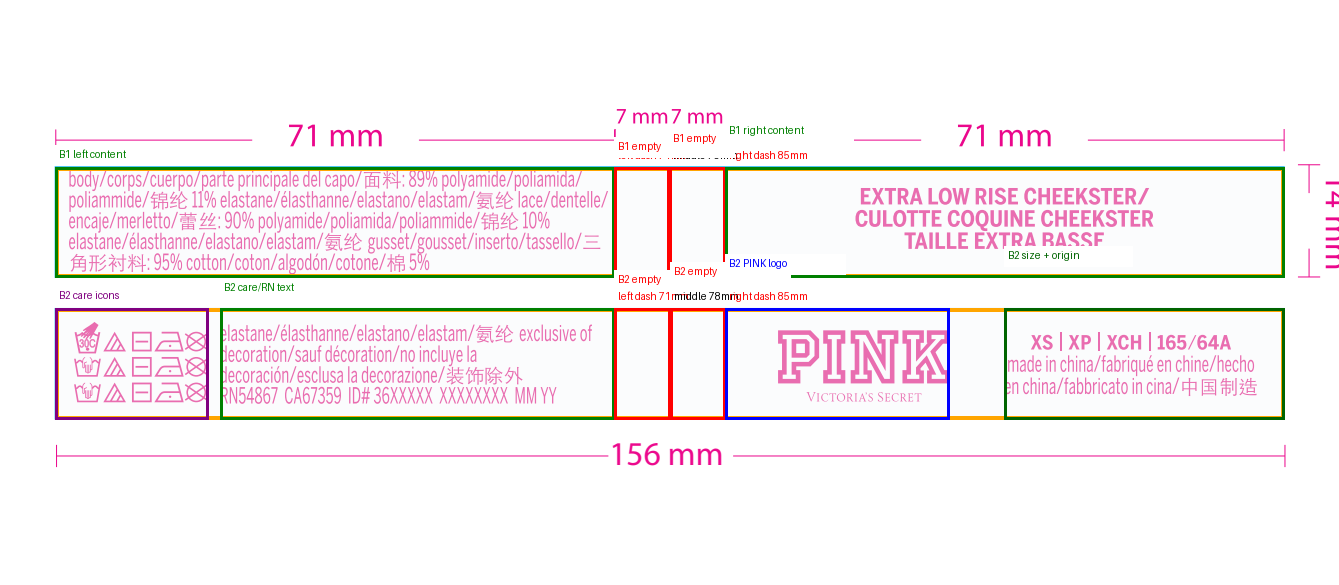

In [4]:
from pathlib import Path
import pdfplumber
import pypdfium2 as pdfium
from PIL import ImageDraw
from IPython.display import display, Image

master_pdf_path = Path("../input_files/LB 07655 C 1 MK not copyable.pdf")
output_dir = Path("../annotated image")
output_dir.mkdir(exist_ok=True)

dpi = 200
scale = dpi / 72
PT_TO_MM = 25.4 / 72

def pt_to_mm(value):
    return value * PT_TO_MM

def render_pdf_page(pdf_path, dpi=200):
    pdf = pdfium.PdfDocument(str(pdf_path))
    page = pdf[0]
    bitmap = page.render(scale=dpi / 72)
    return bitmap.to_pil().convert("RGB")

def is_label_box(rect):
    width_mm = pt_to_mm(rect["width"])
    height_mm = pt_to_mm(rect["height"])
    return 150 <= width_mm <= 160 and 10 <= height_mm <= 20

def get_label_boxes(page):
    boxes = [rect for rect in page.rects if is_label_box(rect)]
    return sorted(boxes, key=lambda box: (box["top"], box["x0"]))

def get_vertical_guides(page, box, tolerance_pt=0.5):
    guides = []

    for line in page.lines:
        if abs(line["x0"] - line["x1"]) >= 0.01:
            continue

        x = line["x0"]
        y0 = min(line["y0"], line["y1"])
        y1 = max(line["y0"], line["y1"])

        if not (box["x0"] <= x <= box["x1"] and y1 >= box["y0"] and y0 <= box["y1"]):
            continue

        matched = None

        for guide in guides:
            if abs(guide["x_pt"] - x) <= tolerance_pt:
                matched = guide
                break

        if matched is None:
            matched = {"x_pt": x, "lines": []}
            guides.append(matched)

        matched["lines"].append(line)

    final_guides = []

    for guide in guides:
        x_avg = sum(line["x0"] for line in guide["lines"]) / len(guide["lines"])
        has_dash = any(line.get("dash") and line.get("dash")[0] for line in guide["lines"])

        final_guides.append({
            "x_pt": x_avg,
            "is_dashed": has_dash,
        })

    return sorted(final_guides, key=lambda guide: guide["x_pt"])

def object_overlaps_bbox(obj, bbox):
    x0, top, x1, bottom = bbox

    return (
        obj.get("x1", 0) > x0 and
        obj.get("x0", 0) < x1 and
        obj.get("bottom", 0) > top and
        obj.get("top", 0) < bottom
    )

def is_box_or_guide_object(obj, box, guides, tolerance_pt=0.8):
    if obj.get("object_type") == "rect":
        is_outer_box = (
            abs(obj.get("x0", 0) - box["x0"]) <= tolerance_pt and
            abs(obj.get("x1", 0) - box["x1"]) <= tolerance_pt and
            abs(obj.get("top", 0) - box["top"]) <= tolerance_pt and
            abs(obj.get("bottom", 0) - box["bottom"]) <= tolerance_pt
        )

        if is_outer_box:
            return True

    if obj.get("object_type") == "line":
        is_vertical = abs(obj.get("x0", 0) - obj.get("x1", 0)) < 0.01

        if is_vertical:
            return any(abs(obj["x0"] - guide["x_pt"]) <= tolerance_pt for guide in guides)

    return False

def get_content_objects(page, box, guides, bbox):
    objects = []

    for obj in page.chars + page.rects + page.curves + page.lines:
        if is_box_or_guide_object(obj, box, guides):
            continue

        if object_overlaps_bbox(obj, bbox):
            objects.append(obj)

    return objects

def merge_intervals(intervals):
    intervals = sorted(intervals)
    merged = []

    for start, end in intervals:
        if not merged or start > merged[-1][1]:
            merged.append([start, end])
        else:
            merged[-1][1] = max(merged[-1][1], end)

    return merged

def find_largest_gap(objects):
    intervals = [(obj["x0"], obj["x1"]) for obj in objects]
    merged = merge_intervals(intervals)

    gaps = []

    for current_interval, next_interval in zip(merged, merged[1:]):
        gap_start = current_interval[1]
        gap_end = next_interval[0]

        gaps.append({
            "gap_size": gap_end - gap_start,
            "gap_start": gap_start,
            "gap_end": gap_end,
        })

    if not gaps:
        return None

    return max(gaps, key=lambda gap: gap["gap_size"])

def to_px_bbox(bbox):
    x0, top, x1, bottom = bbox
    return tuple(round(value * scale) for value in (x0, top, x1, bottom))

def draw_box(draw, bbox, color, label, width=4, label_offset=0):
    x0, y0, x1, y1 = to_px_bbox(bbox)

    draw.rectangle((x0, y0, x1, y1), outline=color, width=width)

    label_width = max(120, len(label) * 8)
    label_y = max(0, y0 - 22 - label_offset)

    draw.rectangle((x0, label_y, x0 + label_width, label_y + 20), fill="white")
    draw.text((x0 + 4, label_y + 3), label, fill=color)

def annotate_master_artwork(master_pdf_path, output_dir, dpi=200):
    image = render_pdf_page(master_pdf_path, dpi=dpi)
    draw = ImageDraw.Draw(image)

    with pdfplumber.open(master_pdf_path) as pdf:
        page = pdf.pages[0]
        boxes = get_label_boxes(page)

        for box_no, box in enumerate(boxes, start=1):
            guides = get_vertical_guides(page, box)[:3]

            if len(guides) < 3:
                continue

            left_dash, middle_line, right_dash = guides

            box_bbox = (box["x0"], box["top"], box["x1"], box["bottom"])
            draw_box(draw, box_bbox, "orange", f"box {box_no}: 156 x 14 mm", width=4)

            for guide_name, guide, color in [
                ("left dash 71mm", left_dash, "red"),
                ("middle 78mm", middle_line, "black"),
                ("right dash 85mm", right_dash, "red"),
            ]:
                x = round(guide["x_pt"] * scale)
                y0 = round(box["top"] * scale)
                y1 = round(box["bottom"] * scale)

                draw.line((x, y0, x, y1), fill=color, width=3)
                draw.text((x + 4, y0 - 18), guide_name, fill=color)

            if box_no == 1:
                zones = [
                    ("B1 left content", (box["x0"], box["top"], left_dash["x_pt"], box["bottom"]), "green"),
                    ("B1 empty", (left_dash["x_pt"], box["top"], middle_line["x_pt"], box["bottom"]), "red"),
                    ("B1 empty", (middle_line["x_pt"], box["top"], right_dash["x_pt"], box["bottom"]), "red"),
                    ("B1 right content", (right_dash["x_pt"], box["top"], box["x1"], box["bottom"]), "green"),
                ]

                for i, (label, bbox, color) in enumerate(zones):
                    draw_box(draw, bbox, color, label, width=3, label_offset=i * 8)

            if box_no == 2:
                left_area = (box["x0"], box["top"], left_dash["x_pt"], box["bottom"])
                middle_left = (left_dash["x_pt"], box["top"], middle_line["x_pt"], box["bottom"])
                middle_right = (middle_line["x_pt"], box["top"], right_dash["x_pt"], box["bottom"])
                right_area = (right_dash["x_pt"], box["top"], box["x1"], box["bottom"])

                left_objects = get_content_objects(page, box, guides, left_area)
                right_objects = get_content_objects(page, box, guides, right_area)

                left_gap = find_largest_gap(left_objects)
                right_gap = find_largest_gap(right_objects)

                care_icon_bbox = (box["x0"], box["top"], left_gap["gap_start"], box["bottom"])
                left_text_bbox = (left_gap["gap_end"], box["top"], left_dash["x_pt"], box["bottom"])

                logo_bbox = (right_dash["x_pt"], box["top"], right_gap["gap_start"], box["bottom"])
                right_text_bbox = (right_gap["gap_end"], box["top"], box["x1"], box["bottom"])

                zones = [
                    ("B2 care icons", care_icon_bbox, "purple"),
                    ("B2 care/RN text", left_text_bbox, "green"),
                    ("B2 empty", middle_left, "red"),
                    ("B2 empty", middle_right, "red"),
                    ("B2 PINK logo", logo_bbox, "blue"),
                    ("B2 size + origin", right_text_bbox, "darkgreen"),
                ]

                for i, (label, bbox, color) in enumerate(zones):
                    draw_box(draw, bbox, color, label, width=3, label_offset=i * 8)

        full_path = output_dir / "master_artwork_structure_annotated_full.png"
        image.save(full_path)

        crop_x0 = min(box["x0"] for box in boxes) - 20
        crop_top = min(box["top"] for box in boxes) - 60
        crop_x1 = max(box["x1"] for box in boxes) + 20
        crop_bottom = max(box["bottom"] for box in boxes) + 60

        crop_bbox = to_px_bbox((crop_x0, crop_top, crop_x1, crop_bottom))
        crop_image = image.crop(crop_bbox)

        crop_path = output_dir / "master_artwork_structure_annotated_crop.png"
        crop_image.save(crop_path)

    return full_path, crop_path

full_image_path, crop_image_path = annotate_master_artwork(
    master_pdf_path=master_pdf_path,
    output_dir=output_dir,
    dpi=dpi
)

print("Full image saved:", full_image_path)
print("Crop image saved:", crop_image_path)

display(Image(filename=str(crop_image_path)))

In [5]:
import json
import pdfplumber

master_pdf_path = "../input_files/LB 07655 C 1 MK not copyable.pdf"

PT_TO_MM = 25.4 / 72

def pt_to_mm(value):
    return value * PT_TO_MM

def rmm(value):
    return round(value, 3)

def is_label_box(rect):
    width_mm = pt_to_mm(rect["width"])
    height_mm = pt_to_mm(rect["height"])
    return 150 <= width_mm <= 160 and 10 <= height_mm <= 20

def get_label_boxes(page):
    boxes = [rect for rect in page.rects if is_label_box(rect)]
    return sorted(boxes, key=lambda box: (box["top"], box["x0"]))

def get_vertical_guides(page, box, tolerance_pt=0.5):
    guides = []

    for line in page.lines:
        if abs(line["x0"] - line["x1"]) >= 0.01:
            continue

        x = line["x0"]
        y0 = min(line["y0"], line["y1"])
        y1 = max(line["y0"], line["y1"])

        if not (box["x0"] <= x <= box["x1"] and y1 >= box["y0"] and y0 <= box["y1"]):
            continue

        if not any(abs(x - guide) <= tolerance_pt for guide in guides):
            guides.append(x)

    return sorted(guides)

def object_overlaps_bbox(obj, bbox):
    x0, top, x1, bottom = bbox

    return (
        obj.get("x1", 0) > x0 and
        obj.get("x0", 0) < x1 and
        obj.get("bottom", 0) > top and
        obj.get("top", 0) < bottom
    )

def is_box_or_guide_object(obj, box, guides, tolerance_pt=0.8):
    if obj.get("object_type") == "rect":
        is_outer_box = (
            abs(obj.get("x0", 0) - box["x0"]) <= tolerance_pt and
            abs(obj.get("x1", 0) - box["x1"]) <= tolerance_pt and
            abs(obj.get("top", 0) - box["top"]) <= tolerance_pt and
            abs(obj.get("bottom", 0) - box["bottom"]) <= tolerance_pt
        )

        if is_outer_box:
            return True

    if obj.get("object_type") == "line":
        is_vertical = abs(obj.get("x0", 0) - obj.get("x1", 0)) < 0.01

        if is_vertical:
            return any(abs(obj["x0"] - guide) <= tolerance_pt for guide in guides)

    return False

def get_content_objects(page, box, guides, bbox):
    objects = []

    all_objects = page.chars + page.rects + page.curves + page.lines

    for obj in all_objects:
        if is_box_or_guide_object(obj, box, guides):
            continue

        if object_overlaps_bbox(obj, bbox):
            objects.append(obj)

    return objects

def merge_intervals(intervals):
    intervals = sorted(intervals)
    merged = []

    for start, end in intervals:
        if not merged or start > merged[-1][1]:
            merged.append([start, end])
        else:
            merged[-1][1] = max(merged[-1][1], end)

    return merged

def find_largest_x_gap(objects):
    intervals = [(obj["x0"], obj["x1"]) for obj in objects]
    merged = merge_intervals(intervals)

    gaps = []

    for current_interval, next_interval in zip(merged, merged[1:]):
        gaps.append({
            "gap_size": next_interval[0] - current_interval[1],
            "gap_start": current_interval[1],
            "gap_end": next_interval[0],
        })

    return max(gaps, key=lambda gap: gap["gap_size"])

def get_bbox(objects):
    if not objects:
        return None

    return {
        "x0": min(obj["x0"] for obj in objects),
        "top": min(obj["top"] for obj in objects),
        "x1": max(obj["x1"] for obj in objects),
        "bottom": max(obj["bottom"] for obj in objects),
    }

def bbox_to_mm(bbox, box):
    if bbox is None:
        return None

    return {
        "x0_mm": rmm(pt_to_mm(bbox["x0"] - box["x0"])),
        "top_mm": rmm(pt_to_mm(bbox["top"] - box["top"])),
        "x1_mm": rmm(pt_to_mm(bbox["x1"] - box["x0"])),
        "bottom_mm": rmm(pt_to_mm(bbox["bottom"] - box["top"])),
        "width_mm": rmm(pt_to_mm(bbox["x1"] - bbox["x0"])),
        "height_mm": rmm(pt_to_mm(bbox["bottom"] - bbox["top"])),
    }

def split_into_y_bands(objects):
    if not objects:
        return []

    intervals = [(obj["top"], obj["bottom"]) for obj in objects]
    merged = merge_intervals(intervals)

    bands = []

    for top, bottom in merged:
        band_objects = [
            obj for obj in objects
            if obj["bottom"] > top and obj["top"] < bottom
        ]

        bands.append({
            "object_count": len(band_objects),
            "bbox": bbox_to_mm(get_bbox(band_objects), current_box),
        })

    return bands

def extract_box_2_structure(master_pdf_path):
    with pdfplumber.open(master_pdf_path) as pdf:
        page = pdf.pages[0]

        boxes = get_label_boxes(page)
        box = boxes[1]   # second label box

        guides = get_vertical_guides(page, box)
        left_dash, middle_line, right_dash = guides[:3]

        left_area = (box["x0"], box["top"], left_dash, box["bottom"])
        middle_left_area = (left_dash, box["top"], middle_line, box["bottom"])
        middle_right_area = (middle_line, box["top"], right_dash, box["bottom"])
        right_area = (right_dash, box["top"], box["x1"], box["bottom"])

        left_objects = get_content_objects(page, box, guides, left_area)
        right_objects = get_content_objects(page, box, guides, right_area)

        left_gap = find_largest_x_gap(left_objects)
        right_gap = find_largest_x_gap(right_objects)

        care_icon_area = (box["x0"], box["top"], left_gap["gap_start"], box["bottom"])
        left_text_area = (left_gap["gap_end"], box["top"], left_dash, box["bottom"])

        logo_area = (right_dash, box["top"], right_gap["gap_start"], box["bottom"])
        right_text_area = (right_gap["gap_end"], box["top"], box["x1"], box["bottom"])

        care_icon_objects = get_content_objects(page, box, guides, care_icon_area)
        left_text_objects = get_content_objects(page, box, guides, left_text_area)

        logo_objects = get_content_objects(page, box, guides, logo_area)
        right_text_objects = get_content_objects(page, box, guides, right_text_area)

        middle_left_objects = get_content_objects(page, box, guides, middle_left_area)
        middle_right_objects = get_content_objects(page, box, guides, middle_right_area)

        global current_box
        current_box = box

        left_text_bands = split_into_y_bands(left_text_objects)
        right_text_bands = split_into_y_bands(right_text_objects)

        care_text_bands = left_text_bands[:-1]
        rn_ca_line_band = left_text_bands[-1] if left_text_bands else None

        size_band = right_text_bands[0] if right_text_bands else None
        country_origin_bands = right_text_bands[1:]

        return {
            "box_no": 2,
            "box_size": {
                "width_mm": rmm(pt_to_mm(box["width"])),
                "height_mm": rmm(pt_to_mm(box["height"])),
            },
            "guide_lines": {
                "left_dash_mm": rmm(pt_to_mm(left_dash - box["x0"])),
                "middle_line_mm": rmm(pt_to_mm(middle_line - box["x0"])),
                "right_dash_mm": rmm(pt_to_mm(right_dash - box["x0"])),
            },
            "care_icons": {
                "required": True,
                "rule": "left side of left area",
                "object_count": len(care_icon_objects),
                "bbox": bbox_to_mm(get_bbox(care_icon_objects), box),
            },
            "care_instruction_text": {
                "required": False,
                "rule": "if present, above RN/CA line and right of care icons",
                "band_count": len(care_text_bands),
                "bands": care_text_bands,
            },
            "rn_ca_line": {
                "required": True,
                "rule": "last/bottom line in left text area",
                "exists": rn_ca_line_band is not None,
                "band": rn_ca_line_band,
            },
            "middle_empty_area": {
                "middle_left_has_content": len(middle_left_objects) > 0,
                "middle_left_object_count": len(middle_left_objects),
                "middle_right_has_content": len(middle_right_objects) > 0,
                "middle_right_object_count": len(middle_right_objects),
            },
            "logo": {
                "required": True,
                "rule": "left side of right area",
                "object_count": len(logo_objects),
                "bbox": bbox_to_mm(get_bbox(logo_objects), box),
            },
            "size": {
                "required": True,
                "rule": "top/first line in right text area after logo",
                "exists": size_band is not None,
                "band": size_band,
            },
            "country_of_origin": {
                "required": True,
                "rule": "below size in right text area after logo",
                "band_count": len(country_origin_bands),
                "bands": country_origin_bands,
            },
        }

box_2_structure = extract_box_2_structure(master_pdf_path)

print(json.dumps(box_2_structure, indent=4, ensure_ascii=False))

{
    "box_no": 2,
    "box_size": {
        "width_mm": 156.0,
        "height_mm": 14.0
    },
    "guide_lines": {
        "left_dash_mm": 71.0,
        "middle_line_mm": 78.0,
        "right_dash_mm": 85.0
    },
    "care_icons": {
        "required": true,
        "rule": "left side of left area",
        "object_count": 63,
        "bbox": {
            "x0_mm": 2.376,
            "top_mm": 1.683,
            "x1_mm": 19.333,
            "bottom_mm": 11.887,
            "width_mm": 16.957,
            "height_mm": 10.204
        }
    },
    "care_instruction_text": {
        "required": false,
        "rule": "if present, above RN/CA line and right of care icons",
        "band_count": 2,
        "bands": [
            {
                "object_count": 78,
                "bbox": {
                    "x0_mm": 20.944,
                    "top_mm": 2.018,
                    "x1_mm": 68.124,
                    "bottom_mm": 4.335,
                    "width_mm": 47.181,
        

In [ ]:
{
    "box_no": 2,
    "box_size": {
        "width_mm": 156.0,
        "height_mm": 14.0
    },
    "guide_lines": {
        "left_dash_mm": 71.0,
        "middle_line_mm": 78.0,
        "right_dash_mm": 85.0
    },
    "care_icons": {
        "required": true,
        "rule": "left side of left area",
        "object_count": 63,
        "bbox": {
            "x0_mm": 2.376,
            "top_mm": 1.683,
            "x1_mm": 19.333,
            "bottom_mm": 11.887,
            "width_mm": 16.957,
            "height_mm": 10.204
        }
    },
    "care_instruction_text": {
        "required": false,
        "rule": "if present, above RN/CA line and right of care icons",
        "band_count": 2,
        "bands": [
            {
                "object_count": 78,
                "bbox": {
                    "x0_mm": 20.944,
                    "top_mm": 2.018,
                    "x1_mm": 68.124,
                    "bottom_mm": 4.335,
                    "width_mm": 47.181,
                    "height_mm": 2.316
                }
            },
            {
                "object_count": 119,
                "bbox": {
                    "x0_mm": 20.946,
                    "top_mm": 4.663,
                    "x1_mm": 59.331,
                    "bottom_mm": 9.655,
                    "width_mm": 38.384,
                    "height_mm": 4.992
                }
            }
        ]
    },
    "rn_ca_line": {
        "required": true,
        "rule": "last/bottom line in left text area",
        "exists": true,
        "band": {
            "object_count": 47,
            "bbox": {
                "x0_mm": 21.017,
                "top_mm": 9.917,
                "x1_mm": 63.626,
                "bottom_mm": 12.088,
                "width_mm": 42.609,
                "height_mm": 2.172
            }
        }
    },
    "middle_empty_area": {
        "middle_left_has_content": false,
        "middle_left_object_count": 0,
        "middle_right_has_content": false,
        "middle_right_object_count": 0
    },
    "logo": {
        "required": true,
        "rule": "left side of right area",
        "object_count": 30,
        "bbox": {
            "x0_mm": 91.756,
            "top_mm": 2.753,
            "x1_mm": 113.548,
            "bottom_mm": 11.795,
            "width_mm": 21.792,
            "height_mm": 9.041
        }
    },
    "size": {
        "required": true,
        "rule": "top/first line in right text area after logo",
        "exists": true,
        "band": {
            "object_count": 22,
            "bbox": {
                "x0_mm": 123.857,
                "top_mm": 3.004,
                "x1_mm": 149.268,
                "bottom_mm": 5.327,
                "width_mm": 25.411,
                "height_mm": 2.323
            }
        }
    },
    "country_of_origin": {
        "required": true,
        "rule": "below size in right text area after logo",
        "band_count": 2,
        "bands": [
            {
                "object_count": 50,
                "bbox": {
                    "x0_mm": 120.965,
                    "top_mm": 5.918,
                    "x1_mm": 152.194,
                    "bottom_mm": 8.572,
                    "width_mm": 31.23,
                    "height_mm": 2.654
                }
            },
            {
                "object_count": 52,
                "bbox": {
                    "x0_mm": 120.52,
                    "top_mm": 8.74,
                    "x1_mm": 152.548,
                    "bottom_mm": 11.097,
                    "width_mm": 32.028,
                    "height_mm": 2.357
                }
            }
        ]
    }
}

Full image saved: ../annotated image/master_box_2_detection_annotated_full.png
Crop image saved: ../annotated image/master_box_2_detection_annotated_crop.png


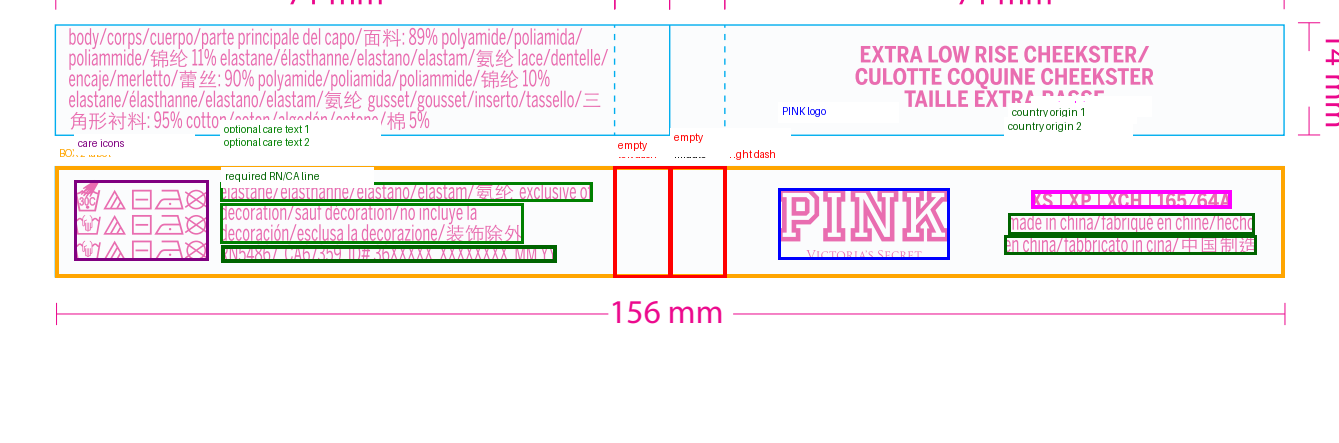

In [6]:
from pathlib import Path
import pypdfium2 as pdfium
from PIL import ImageDraw
from IPython.display import display, Image

master_pdf_path = Path("../input_files/LB 07655 C 1 MK not copyable.pdf")
output_dir = Path("../annotated image")
output_dir.mkdir(exist_ok=True)

dpi = 200
scale = dpi / 72

def render_pdf_page(pdf_path, dpi=200):
    pdf = pdfium.PdfDocument(str(pdf_path))
    page = pdf[0]
    bitmap = page.render(scale=dpi / 72)
    return bitmap.to_pil().convert("RGB")

def to_px_bbox(bbox):
    x0, top, x1, bottom = bbox
    return tuple(round(value * scale) for value in (x0, top, x1, bottom))

def draw_box(draw, bbox, color, label, width=4, label_offset=0):
    x0, y0, x1, y1 = to_px_bbox(bbox)

    draw.rectangle((x0, y0, x1, y1), outline=color, width=width)

    label_width = max(120, len(label) * 8)
    label_y = max(0, y0 - 22 - label_offset)

    draw.rectangle((x0, label_y, x0 + label_width, label_y + 20), fill="white")
    draw.text((x0 + 4, label_y + 3), label, fill=color)

def bbox_from_mm(relative_bbox, box):
    return (
        box["x0"] + (relative_bbox["x0_mm"] / PT_TO_MM),
        box["top"] + (relative_bbox["top_mm"] / PT_TO_MM),
        box["x0"] + (relative_bbox["x1_mm"] / PT_TO_MM),
        box["top"] + (relative_bbox["bottom_mm"] / PT_TO_MM),
    )

def annotate_box_2_detection(master_pdf_path, output_dir, dpi=200):
    image = render_pdf_page(master_pdf_path, dpi=dpi)
    draw = ImageDraw.Draw(image)

    with pdfplumber.open(master_pdf_path) as pdf:
        page = pdf.pages[0]

        boxes = get_label_boxes(page)
        box = boxes[1]

        guides = get_vertical_guides(page, box)
        left_dash, middle_line, right_dash = guides[:3]

        # Run extraction again so annotation follows exact logic
        structure = extract_box_2_structure(str(master_pdf_path))

        # Main box
        box_bbox = (box["x0"], box["top"], box["x1"], box["bottom"])
        draw_box(draw, box_bbox, "orange", "BOX 2 label", width=4)

        # Guide lines
        for label, x, color in [
            ("left dash", left_dash, "red"),
            ("middle", middle_line, "black"),
            ("right dash", right_dash, "red"),
        ]:
            x_px = round(x * scale)
            y0_px = round(box["top"] * scale)
            y1_px = round(box["bottom"] * scale)

            draw.line((x_px, y0_px, x_px, y1_px), fill=color, width=3)
            draw.text((x_px + 4, y0_px - 18), label, fill=color)

        # Middle empty zones
        middle_left_bbox = (left_dash, box["top"], middle_line, box["bottom"])
        middle_right_bbox = (middle_line, box["top"], right_dash, box["bottom"])

        draw_box(draw, middle_left_bbox, "red", "empty", width=3, label_offset=8)
        draw_box(draw, middle_right_bbox, "red", "empty", width=3, label_offset=16)

        # Care icons
        care_icons_bbox = bbox_from_mm(structure["care_icons"]["bbox"], box)
        draw_box(draw, care_icons_bbox, "purple", "care icons", width=3, label_offset=24)

        # Optional care instruction text bands
        for i, band in enumerate(structure["care_instruction_text"]["bands"], start=1):
            if not band or not band["bbox"]:
                continue

            band_bbox = bbox_from_mm(band["bbox"], box)
            draw_box(
                draw,
                band_bbox,
                "green",
                f"optional care text {i}",
                width=3,
                label_offset=32 + i * 8,
            )

        # Required RN/CA line
        rn_band = structure["rn_ca_line"]["band"]
        if rn_band and rn_band["bbox"]:
            rn_bbox = bbox_from_mm(rn_band["bbox"], box)
            draw_box(draw, rn_bbox, "darkgreen", "required RN/CA line", width=4, label_offset=56)

        # Logo
        logo_bbox = bbox_from_mm(structure["logo"]["bbox"], box)
        draw_box(draw, logo_bbox, "blue", "PINK logo", width=3, label_offset=64)

        # Required size
        size_band = structure["size"]["band"]
        if size_band and size_band["bbox"]:
            size_bbox = bbox_from_mm(size_band["bbox"], box)
            draw_box(draw, size_bbox, "magenta", "required size", width=4, label_offset=72)

        # Country of origin bands
        for i, band in enumerate(structure["country_of_origin"]["bands"], start=1):
            if not band or not band["bbox"]:
                continue

            country_bbox = bbox_from_mm(band["bbox"], box)
            draw_box(
                draw,
                country_bbox,
                "darkgreen",
                f"country origin {i}",
                width=3,
                label_offset=80 + i * 8,
            )

        full_path = output_dir / "master_box_2_detection_annotated_full.png"
        image.save(full_path)

        crop_x0 = box["x0"] - 20
        crop_top = box["top"] - 60
        crop_x1 = box["x1"] + 20
        crop_bottom = box["bottom"] + 60

        crop = image.crop(to_px_bbox((crop_x0, crop_top, crop_x1, crop_bottom)))
        crop_path = output_dir / "master_box_2_detection_annotated_crop.png"
        crop.save(crop_path)

    return full_path, crop_path

full_image_path, crop_image_path = annotate_box_2_detection(
    master_pdf_path=master_pdf_path,
    output_dir=output_dir,
    dpi=dpi,
)

print("Full image saved:", full_image_path)
print("Crop image saved:", crop_image_path)

display(Image(filename=str(crop_image_path)))

In [2]:
import json
import pdfplumber

master_pdf_path = "../input_files/LB 07655 C 1 MK not copyable.pdf"

PT_TO_MM = 25.4 / 72

def pt_to_mm(value):
    return value * PT_TO_MM

def rmm(value):
    return round(value, 3)

def is_label_box(rect):
    width_mm = pt_to_mm(rect["width"])
    height_mm = pt_to_mm(rect["height"])
    return 150 <= width_mm <= 160 and 10 <= height_mm <= 20

def get_label_boxes(page):
    boxes = [rect for rect in page.rects if is_label_box(rect)]
    return sorted(boxes, key=lambda box: (box["top"], box["x0"]))

def get_vertical_guides(page, box, tolerance_pt=0.5):
    guides = []

    for line in page.lines:
        if abs(line["x0"] - line["x1"]) >= 0.01:
            continue

        x = line["x0"]
        y0 = min(line["y0"], line["y1"])
        y1 = max(line["y0"], line["y1"])

        if box["x0"] <= x <= box["x1"] and y1 >= box["y0"] and y0 <= box["y1"]:
            if not any(abs(x - guide) <= tolerance_pt for guide in guides):
                guides.append(x)

    return sorted(guides)

def object_overlaps_bbox(obj, bbox):
    x0, top, x1, bottom = bbox

    return (
        obj.get("x1", 0) > x0 and
        obj.get("x0", 0) < x1 and
        obj.get("bottom", 0) > top and
        obj.get("top", 0) < bottom
    )

def is_box_or_guide_object(obj, box, guides, tolerance_pt=0.8):
    if obj.get("object_type") == "rect":
        is_outer_box = (
            abs(obj.get("x0", 0) - box["x0"]) <= tolerance_pt and
            abs(obj.get("x1", 0) - box["x1"]) <= tolerance_pt and
            abs(obj.get("top", 0) - box["top"]) <= tolerance_pt and
            abs(obj.get("bottom", 0) - box["bottom"]) <= tolerance_pt
        )
        if is_outer_box:
            return True

    if obj.get("object_type") == "line":
        is_vertical = abs(obj.get("x0", 0) - obj.get("x1", 0)) < 0.01
        if is_vertical:
            return any(abs(obj["x0"] - guide) <= tolerance_pt for guide in guides)

    return False

def get_content_objects(page, box, guides, bbox):
    objects = []

    all_objects = page.chars + page.rects + page.curves + page.lines

    for obj in all_objects:
        if is_box_or_guide_object(obj, box, guides):
            continue

        if object_overlaps_bbox(obj, bbox):
            objects.append(obj)

    return objects

def merge_intervals(intervals):
    intervals = sorted(intervals)
    merged = []

    for start, end in intervals:
        if not merged or start > merged[-1][1]:
            merged.append([start, end])
        else:
            merged[-1][1] = max(merged[-1][1], end)

    return merged

def find_largest_x_gap(objects):
    intervals = [(obj["x0"], obj["x1"]) for obj in objects]
    merged = merge_intervals(intervals)

    gaps = []

    for current_interval, next_interval in zip(merged, merged[1:]):
        gaps.append({
            "gap_size": next_interval[0] - current_interval[1],
            "gap_start": current_interval[1],
            "gap_end": next_interval[0],
        })

    return max(gaps, key=lambda gap: gap["gap_size"])

def get_bbox(objects):
    if not objects:
        return None

    return {
        "x0": min(obj["x0"] for obj in objects),
        "top": min(obj["top"] for obj in objects),
        "x1": max(obj["x1"] for obj in objects),
        "bottom": max(obj["bottom"] for obj in objects),
    }

def bbox_to_mm(bbox, box):
    if bbox is None:
        return None

    return {
        "x0_mm": rmm(pt_to_mm(bbox["x0"] - box["x0"])),
        "top_mm": rmm(pt_to_mm(bbox["top"] - box["top"])),
        "x1_mm": rmm(pt_to_mm(bbox["x1"] - box["x0"])),
        "bottom_mm": rmm(pt_to_mm(bbox["bottom"] - box["top"])),
        "width_mm": rmm(pt_to_mm(bbox["x1"] - bbox["x0"])),
        "height_mm": rmm(pt_to_mm(bbox["bottom"] - bbox["top"])),
    }

def split_into_y_bands(objects):
    if not objects:
        return []

    intervals = [(obj["top"], obj["bottom"]) for obj in objects]
    merged = merge_intervals(intervals)

    bands = []

    for top, bottom in merged:
        band_objects = [
            obj for obj in objects
            if obj["bottom"] > top and obj["top"] < bottom
        ]

        bands.append({
            "top": top,
            "bottom": bottom,
            "objects": band_objects,
            "bbox": get_bbox(band_objects),
        })

    return bands

def merge_bands_to_section(bands):
    all_objects = []

    for band in bands:
        all_objects.extend(band["objects"])

    return all_objects

def extract_box_2_section_areas(master_pdf_path):
    with pdfplumber.open(master_pdf_path) as pdf:
        page = pdf.pages[0]

        boxes = get_label_boxes(page)
        box = boxes[1]

        guides = get_vertical_guides(page, box)
        left_dash, middle_line, right_dash = guides[:3]

        left_area = (box["x0"], box["top"], left_dash, box["bottom"])
        middle_left_area = (left_dash, box["top"], middle_line, box["bottom"])
        middle_right_area = (middle_line, box["top"], right_dash, box["bottom"])
        right_area = (right_dash, box["top"], box["x1"], box["bottom"])

        left_objects = get_content_objects(page, box, guides, left_area)
        right_objects = get_content_objects(page, box, guides, right_area)

        left_gap = find_largest_x_gap(left_objects)
        right_gap = find_largest_x_gap(right_objects)

        care_icon_area = (box["x0"], box["top"], left_gap["gap_start"], box["bottom"])
        left_text_area = (left_gap["gap_end"], box["top"], left_dash, box["bottom"])

        logo_area = (right_dash, box["top"], right_gap["gap_start"], box["bottom"])
        right_text_area = (right_gap["gap_end"], box["top"], box["x1"], box["bottom"])

        care_icon_objects = get_content_objects(page, box, guides, care_icon_area)
        left_text_objects = get_content_objects(page, box, guides, left_text_area)

        logo_objects = get_content_objects(page, box, guides, logo_area)
        right_text_objects = get_content_objects(page, box, guides, right_text_area)

        middle_left_objects = get_content_objects(page, box, guides, middle_left_area)
        middle_right_objects = get_content_objects(page, box, guides, middle_right_area)

        left_text_bands = split_into_y_bands(left_text_objects)
        right_text_bands = split_into_y_bands(right_text_objects)

        care_instruction_bands = left_text_bands[:-1]
        rn_ca_band = left_text_bands[-1] if left_text_bands else None

        size_band = right_text_bands[0] if right_text_bands else None
        country_origin_bands = right_text_bands[1:]

        care_instruction_objects = merge_bands_to_section(care_instruction_bands)
        rn_ca_objects = rn_ca_band["objects"] if rn_ca_band else []

        size_objects = size_band["objects"] if size_band else []
        country_origin_objects = merge_bands_to_section(country_origin_bands)

        return {
            "box_no": 2,
            "box_size": {
                "width_mm": rmm(pt_to_mm(box["width"])),
                "height_mm": rmm(pt_to_mm(box["height"])),
            },
            "guide_lines": {
                "left_dash_mm": rmm(pt_to_mm(left_dash - box["x0"])),
                "middle_line_mm": rmm(pt_to_mm(middle_line - box["x0"])),
                "right_dash_mm": rmm(pt_to_mm(right_dash - box["x0"])),
            },
            "sections": {
                "care_icons": {
                    "required": True,
                    "bbox": bbox_to_mm(get_bbox(care_icon_objects), box),
                    "object_count": len(care_icon_objects),
                },
                "care_instruction_text": {
                    "required": False,
                    "bbox": bbox_to_mm(get_bbox(care_instruction_objects), box),
                    "object_count": len(care_instruction_objects),
                    "line_count": len(care_instruction_bands),
                },
                "rn_ca_line": {
                    "required": True,
                    "bbox": bbox_to_mm(get_bbox(rn_ca_objects), box),
                    "object_count": len(rn_ca_objects),
                    "line_count": 1 if rn_ca_objects else 0,
                },
                "middle_left_empty": {
                    "required": True,
                    "has_content": len(middle_left_objects) > 0,
                    "object_count": len(middle_left_objects),
                },
                "middle_right_empty": {
                    "required": True,
                    "has_content": len(middle_right_objects) > 0,
                    "object_count": len(middle_right_objects),
                },
                "logo": {
                    "required": True,
                    "bbox": bbox_to_mm(get_bbox(logo_objects), box),
                    "object_count": len(logo_objects),
                },
                "size": {
                    "required": True,
                    "bbox": bbox_to_mm(get_bbox(size_objects), box),
                    "object_count": len(size_objects),
                    "line_count": 1 if size_objects else 0,
                },
                "country_of_origin": {
                    "required": True,
                    "bbox": bbox_to_mm(get_bbox(country_origin_objects), box),
                    "object_count": len(country_origin_objects),
                    "line_count": len(country_origin_bands),
                },
            },
        }

box_2_section_areas = extract_box_2_section_areas(master_pdf_path)

print(json.dumps(box_2_section_areas, indent=4, ensure_ascii=False))

{
    "box_no": 2,
    "box_size": {
        "width_mm": 156.0,
        "height_mm": 14.0
    },
    "guide_lines": {
        "left_dash_mm": 71.0,
        "middle_line_mm": 78.0,
        "right_dash_mm": 85.0
    },
    "sections": {
        "care_icons": {
            "required": true,
            "bbox": {
                "x0_mm": 2.376,
                "top_mm": 1.683,
                "x1_mm": 19.333,
                "bottom_mm": 11.887,
                "width_mm": 16.957,
                "height_mm": 10.204
            },
            "object_count": 63
        },
        "care_instruction_text": {
            "required": false,
            "bbox": {
                "x0_mm": 20.944,
                "top_mm": 2.018,
                "x1_mm": 68.124,
                "bottom_mm": 9.655,
                "width_mm": 47.181,
                "height_mm": 7.636
            },
            "object_count": 197,
            "line_count": 2
        },
        "rn_ca_line": {
            "require

In [ ]:
{
    "box_no": 2,
    "box_size": {
        "width_mm": 156.0,
        "height_mm": 14.0
    },
    "guide_lines": {
        "left_dash_mm": 71.0,
        "middle_line_mm": 78.0,
        "right_dash_mm": 85.0
    },
    "sections": {
        "care_icons": {
            "required": true,
            "bbox": {
                "x0_mm": 2.376,
                "top_mm": 1.683,
                "x1_mm": 19.333,
                "bottom_mm": 11.887,
                "width_mm": 16.957,
                "height_mm": 10.204
            },
            "object_count": 63
        },
        "care_instruction_text": {
            "required": false,
            "bbox": {
                "x0_mm": 20.944,
                "top_mm": 2.018,
                "x1_mm": 68.124,
                "bottom_mm": 9.655,
                "width_mm": 47.181,
                "height_mm": 7.636
            },
            "object_count": 197,
            "line_count": 2
        },
        "rn_ca_line": {
            "required": true,
            "bbox": {
                "x0_mm": 21.017,
                "top_mm": 9.917,
                "x1_mm": 63.626,
                "bottom_mm": 12.088,
                "width_mm": 42.609,
                "height_mm": 2.172
            },
            "object_count": 47,
            "line_count": 1
        },
        "middle_left_empty": {
            "required": true,
            "has_content": false,
            "object_count": 0
        },
        "middle_right_empty": {
            "required": true,
            "has_content": false,
            "object_count": 0
        },
        "logo": {
            "required": true,
            "bbox": {
                "x0_mm": 91.756,
                "top_mm": 2.753,
                "x1_mm": 113.548,
                "bottom_mm": 11.795,
                "width_mm": 21.792,
                "height_mm": 9.041
            },
            "object_count": 30
        },
        "size": {
            "required": true,
            "bbox": {
                "x0_mm": 123.857,
                "top_mm": 3.004,
                "x1_mm": 149.268,
                "bottom_mm": 5.327,
                "width_mm": 25.411,
                "height_mm": 2.323
            },
            "object_count": 22,
            "line_count": 1
        },
        "country_of_origin": {
            "required": true,
            "bbox": {
                "x0_mm": 120.52,
                "top_mm": 5.918,
                "x1_mm": 152.548,
                "bottom_mm": 11.097,
                "width_mm": 32.028,
                "height_mm": 5.179
            },
            "object_count": 102,
            "line_count": 2
        }
    }
}

Full image saved: ../annotated image/master_box_2_sections_annotated_full.png
Crop image saved: ../annotated image/master_box_2_sections_annotated_crop.png


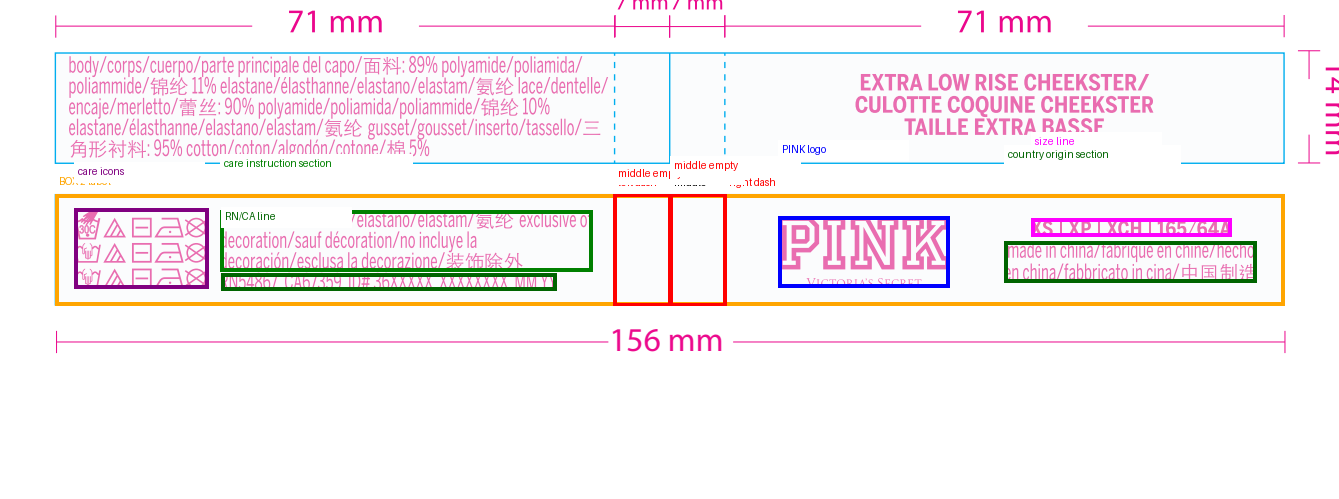

In [3]:
from pathlib import Path
import pypdfium2 as pdfium
from PIL import ImageDraw
from IPython.display import display, Image

master_pdf_path = Path("../input_files/LB 07655 C 1 MK not copyable.pdf")
output_dir = Path("../annotated image")
output_dir.mkdir(exist_ok=True)

dpi = 200
scale = dpi / 72

def render_pdf_page(pdf_path, dpi=200):
    pdf = pdfium.PdfDocument(str(pdf_path))
    page = pdf[0]
    bitmap = page.render(scale=dpi / 72)
    return bitmap.to_pil().convert("RGB")

def to_px_bbox(bbox):
    x0, top, x1, bottom = bbox
    return tuple(round(value * scale) for value in (x0, top, x1, bottom))

def draw_box(draw, bbox, color, label, width=4, label_offset=0):
    x0, y0, x1, y1 = to_px_bbox(bbox)

    draw.rectangle((x0, y0, x1, y1), outline=color, width=width)

    label_width = max(130, len(label) * 8)
    label_y = max(0, y0 - 22 - label_offset)

    draw.rectangle((x0, label_y, x0 + label_width, label_y + 20), fill="white")
    draw.text((x0 + 4, label_y + 3), label, fill=color)

def bbox_from_mm(relative_bbox, box):
    if relative_bbox is None:
        return None

    return (
        box["x0"] + (relative_bbox["x0_mm"] / PT_TO_MM),
        box["top"] + (relative_bbox["top_mm"] / PT_TO_MM),
        box["x0"] + (relative_bbox["x1_mm"] / PT_TO_MM),
        box["top"] + (relative_bbox["bottom_mm"] / PT_TO_MM),
    )

def annotate_box_2_sections(master_pdf_path, output_dir, dpi=200):
    image = render_pdf_page(master_pdf_path, dpi=dpi)
    draw = ImageDraw.Draw(image)

    section_data = extract_box_2_section_areas(str(master_pdf_path))

    with pdfplumber.open(master_pdf_path) as pdf:
        page = pdf.pages[0]

        boxes = get_label_boxes(page)
        box = boxes[1]

        guides = get_vertical_guides(page, box)
        left_dash, middle_line, right_dash = guides[:3]

        # Draw label box
        box_bbox = (box["x0"], box["top"], box["x1"], box["bottom"])
        draw_box(draw, box_bbox, "orange", "BOX 2 label", width=4)

        # Draw guide lines
        for label, x, color in [
            ("left dash", left_dash, "red"),
            ("middle", middle_line, "black"),
            ("right dash", right_dash, "red"),
        ]:
            x_px = round(x * scale)
            y0_px = round(box["top"] * scale)
            y1_px = round(box["bottom"] * scale)

            draw.line((x_px, y0_px, x_px, y1_px), fill=color, width=3)
            draw.text((x_px + 4, y0_px - 18), label, fill=color)

        # Draw empty middle zones
        middle_left_bbox = (left_dash, box["top"], middle_line, box["bottom"])
        middle_right_bbox = (middle_line, box["top"], right_dash, box["bottom"])

        draw_box(draw, middle_left_bbox, "red", "middle empty", width=3, label_offset=8)
        draw_box(draw, middle_right_bbox, "red", "middle empty", width=3, label_offset=16)

        sections = section_data["sections"]

        draw_plan = [
            ("care_icons", "purple", "care icons"),
            ("care_instruction_text", "green", "care instruction section"),
            ("rn_ca_line", "darkgreen", "RN/CA line"),
            ("logo", "blue", "PINK logo"),
            ("size", "magenta", "size line"),
            ("country_of_origin", "darkgreen", "country origin section"),
        ]

        label_offset = 24

        for key, color, label in draw_plan:
            bbox_mm = sections[key]["bbox"]

            if bbox_mm is None:
                continue

            bbox = bbox_from_mm(bbox_mm, box)

            draw_box(
                draw=draw,
                bbox=bbox,
                color=color,
                label=label,
                width=4,
                label_offset=label_offset,
            )

            label_offset += 10

        full_path = output_dir / "master_box_2_sections_annotated_full.png"
        image.save(full_path)

        crop_x0 = box["x0"] - 20
        crop_top = box["top"] - 70
        crop_x1 = box["x1"] + 20
        crop_bottom = box["bottom"] + 70

        crop = image.crop(to_px_bbox((crop_x0, crop_top, crop_x1, crop_bottom)))

        crop_path = output_dir / "master_box_2_sections_annotated_crop.png"
        crop.save(crop_path)

    return full_path, crop_path

full_image_path, crop_image_path = annotate_box_2_sections(
    master_pdf_path=master_pdf_path,
    output_dir=output_dir,
    dpi=dpi,
)

print("Full image saved:", full_image_path)
print("Crop image saved:", crop_image_path)

display(Image(filename=str(crop_image_path)))

# Final Code to find content (care instruction, icon, logo, etc.)

In [4]:
import json
import pdfplumber

master_pdf_path = "../input_files/LB 07655 C 1 MK not copyable.pdf"

PT_TO_MM = 25.4 / 72

def pt_to_mm(value):
    return value * PT_TO_MM

def rmm(value):
    return round(value, 3)

def is_label_box(rect):
    width_mm = pt_to_mm(rect["width"])
    height_mm = pt_to_mm(rect["height"])
    return 150 <= width_mm <= 160 and 10 <= height_mm <= 20

def get_label_boxes(page):
    boxes = [rect for rect in page.rects if is_label_box(rect)]
    return sorted(boxes, key=lambda box: (box["top"], box["x0"]))

def get_vertical_guides(page, box, tolerance_pt=0.5):
    guides = []

    for line in page.lines:
        if abs(line["x0"] - line["x1"]) >= 0.01:
            continue

        x = line["x0"]
        y0 = min(line["y0"], line["y1"])
        y1 = max(line["y0"], line["y1"])

        if box["x0"] <= x <= box["x1"] and y1 >= box["y0"] and y0 <= box["y1"]:
            if not any(abs(x - guide) <= tolerance_pt for guide in guides):
                guides.append(x)

    return sorted(guides)

def object_overlaps_bbox(obj, bbox):
    x0, top, x1, bottom = bbox

    return (
        obj.get("x1", 0) > x0 and
        obj.get("x0", 0) < x1 and
        obj.get("bottom", 0) > top and
        obj.get("top", 0) < bottom
    )

def is_box_or_guide_object(obj, box, guides, tolerance_pt=0.8):
    if obj.get("object_type") == "rect":
        is_outer_box = (
            abs(obj.get("x0", 0) - box["x0"]) <= tolerance_pt and
            abs(obj.get("x1", 0) - box["x1"]) <= tolerance_pt and
            abs(obj.get("top", 0) - box["top"]) <= tolerance_pt and
            abs(obj.get("bottom", 0) - box["bottom"]) <= tolerance_pt
        )

        if is_outer_box:
            return True

    if obj.get("object_type") == "line":
        is_vertical = abs(obj.get("x0", 0) - obj.get("x1", 0)) < 0.01

        if is_vertical:
            return any(abs(obj["x0"] - guide) <= tolerance_pt for guide in guides)

    return False

def get_content_objects(page, box, guides, bbox):
    objects = []

    all_objects = page.chars + page.rects + page.curves + page.lines

    for obj in all_objects:
        if is_box_or_guide_object(obj, box, guides):
            continue

        if object_overlaps_bbox(obj, bbox):
            objects.append(obj)

    return objects

def merge_intervals(intervals):
    intervals = sorted(intervals)
    merged = []

    for start, end in intervals:
        if not merged or start > merged[-1][1]:
            merged.append([start, end])
        else:
            merged[-1][1] = max(merged[-1][1], end)

    return merged

def find_largest_x_gap(objects):
    intervals = [(obj["x0"], obj["x1"]) for obj in objects]
    merged = merge_intervals(intervals)

    gaps = []

    for current_interval, next_interval in zip(merged, merged[1:]):
        gaps.append({
            "gap_size": next_interval[0] - current_interval[1],
            "gap_start": current_interval[1],
            "gap_end": next_interval[0],
        })

    if not gaps:
        return None

    return max(gaps, key=lambda gap: gap["gap_size"])

def get_bbox(objects):
    if not objects:
        return None

    return {
        "x0": min(obj["x0"] for obj in objects),
        "top": min(obj["top"] for obj in objects),
        "x1": max(obj["x1"] for obj in objects),
        "bottom": max(obj["bottom"] for obj in objects),
    }

def bbox_to_mm(bbox, box):
    if bbox is None:
        return None

    return {
        "x0_mm": rmm(pt_to_mm(bbox["x0"] - box["x0"])),
        "top_mm": rmm(pt_to_mm(bbox["top"] - box["top"])),
        "x1_mm": rmm(pt_to_mm(bbox["x1"] - box["x0"])),
        "bottom_mm": rmm(pt_to_mm(bbox["bottom"] - box["top"])),
        "width_mm": rmm(pt_to_mm(bbox["x1"] - bbox["x0"])),
        "height_mm": rmm(pt_to_mm(bbox["bottom"] - bbox["top"])),
    }

def split_into_y_bands(objects):
    if not objects:
        return []

    intervals = [(obj["top"], obj["bottom"]) for obj in objects]
    merged = merge_intervals(intervals)

    bands = []

    for top, bottom in merged:
        band_objects = [
            obj for obj in objects
            if obj["bottom"] > top and obj["top"] < bottom
        ]

        bands.append({
            "objects": band_objects,
            "bbox": get_bbox(band_objects),
        })

    return bands

def merge_bands_to_objects(bands):
    objects = []

    for band in bands:
        objects.extend(band["objects"])

    return objects

In [5]:
def extract_box_1_structure(page, box, guides):
    left_dash, middle_line, right_dash = guides[:3]

    zones = {
        "left_content": (box["x0"], box["top"], left_dash, box["bottom"]),
        "middle_left_empty": (left_dash, box["top"], middle_line, box["bottom"]),
        "middle_right_empty": (middle_line, box["top"], right_dash, box["bottom"]),
        "right_content": (right_dash, box["top"], box["x1"], box["bottom"]),
    }

    sections = {}

    for section_name, bbox in zones.items():
        objects = get_content_objects(page, box, guides, bbox)

        sections[section_name] = {
            "bbox": bbox_to_mm(get_bbox(objects), box),
            "object_count": len(objects),
            "has_content": len(objects) > 0,
        }

    return {
        "box_type": "text_only_label",
        "sections": sections,
    }

def extract_box_2_structure(page, box, guides):
    left_dash, middle_line, right_dash = guides[:3]

    left_area = (box["x0"], box["top"], left_dash, box["bottom"])
    middle_left_area = (left_dash, box["top"], middle_line, box["bottom"])
    middle_right_area = (middle_line, box["top"], right_dash, box["bottom"])
    right_area = (right_dash, box["top"], box["x1"], box["bottom"])

    left_objects = get_content_objects(page, box, guides, left_area)
    right_objects = get_content_objects(page, box, guides, right_area)

    left_gap = find_largest_x_gap(left_objects)
    right_gap = find_largest_x_gap(right_objects)

    care_icon_area = (box["x0"], box["top"], left_gap["gap_start"], box["bottom"])
    left_text_area = (left_gap["gap_end"], box["top"], left_dash, box["bottom"])

    logo_area = (right_dash, box["top"], right_gap["gap_start"], box["bottom"])
    right_text_area = (right_gap["gap_end"], box["top"], box["x1"], box["bottom"])

    care_icon_objects = get_content_objects(page, box, guides, care_icon_area)
    left_text_objects = get_content_objects(page, box, guides, left_text_area)

    logo_objects = get_content_objects(page, box, guides, logo_area)
    right_text_objects = get_content_objects(page, box, guides, right_text_area)

    middle_left_objects = get_content_objects(page, box, guides, middle_left_area)
    middle_right_objects = get_content_objects(page, box, guides, middle_right_area)

    left_text_bands = split_into_y_bands(left_text_objects)
    right_text_bands = split_into_y_bands(right_text_objects)

    care_instruction_bands = left_text_bands[:-1]
    rn_ca_band = left_text_bands[-1] if left_text_bands else None

    size_band = right_text_bands[0] if right_text_bands else None
    country_origin_bands = right_text_bands[1:]

    care_instruction_objects = merge_bands_to_objects(care_instruction_bands)
    rn_ca_objects = rn_ca_band["objects"] if rn_ca_band else []

    size_objects = size_band["objects"] if size_band else []
    country_origin_objects = merge_bands_to_objects(country_origin_bands)

    return {
        "box_type": "care_logo_size_country_label",
        "sections": {
            "care_icons": {
                "required": True,
                "bbox": bbox_to_mm(get_bbox(care_icon_objects), box),
                "object_count": len(care_icon_objects),
            },
            "care_instruction_text": {
                "required": False,
                "bbox": bbox_to_mm(get_bbox(care_instruction_objects), box),
                "object_count": len(care_instruction_objects),
                "line_count": len(care_instruction_bands),
            },
            "rn_ca_line": {
                "required": True,
                "bbox": bbox_to_mm(get_bbox(rn_ca_objects), box),
                "object_count": len(rn_ca_objects),
                "line_count": 1 if rn_ca_objects else 0,
            },
            "middle_left_empty": {
                "required": True,
                "bbox": None,
                "has_content": len(middle_left_objects) > 0,
                "object_count": len(middle_left_objects),
            },
            "middle_right_empty": {
                "required": True,
                "bbox": None,
                "has_content": len(middle_right_objects) > 0,
                "object_count": len(middle_right_objects),
            },
            "logo": {
                "required": True,
                "bbox": bbox_to_mm(get_bbox(logo_objects), box),
                "object_count": len(logo_objects),
            },
            "size": {
                "required": True,
                "bbox": bbox_to_mm(get_bbox(size_objects), box),
                "object_count": len(size_objects),
                "line_count": 1 if size_objects else 0,
            },
            "country_of_origin": {
                "required": True,
                "bbox": bbox_to_mm(get_bbox(country_origin_objects), box),
                "object_count": len(country_origin_objects),
                "line_count": len(country_origin_bands),
            },
        },
    }

In [6]:
def extract_master_artwork_structure(master_pdf_path):
    master_structure = []

    with pdfplumber.open(master_pdf_path) as pdf:
        page = pdf.pages[0]
        boxes = get_label_boxes(page)

        for box_no, box in enumerate(boxes, start=1):
            guides = get_vertical_guides(page, box)

            if len(guides) < 3:
                master_structure.append({
                    "box_no": box_no,
                    "error": "Could not find 3 vertical guide lines",
                    "guide_count": len(guides),
                })
                continue

            guides = guides[:3]
            left_dash, middle_line, right_dash = guides

            box_data = {
                "box_no": box_no,
                "box_size": {
                    "width_mm": rmm(pt_to_mm(box["width"])),
                    "height_mm": rmm(pt_to_mm(box["height"])),
                },
                "guide_lines": {
                    "left_dash_mm": rmm(pt_to_mm(left_dash - box["x0"])),
                    "middle_line_mm": rmm(pt_to_mm(middle_line - box["x0"])),
                    "right_dash_mm": rmm(pt_to_mm(right_dash - box["x0"])),
                },
                "middle_line_is_center": abs(
                    pt_to_mm(middle_line - box["x0"]) - (pt_to_mm(box["width"]) / 2)
                ) <= 0.05,
            }

            if box_no == 1:
                box_data.update(extract_box_1_structure(page, box, guides))

            elif box_no == 2:
                box_data.update(extract_box_2_structure(page, box, guides))

            master_structure.append(box_data)

    return master_structure

master_structure = extract_master_artwork_structure(master_pdf_path)

print(json.dumps(master_structure, indent=4, ensure_ascii=False))

[
    {
        "box_no": 1,
        "box_size": {
            "width_mm": 156.0,
            "height_mm": 14.0
        },
        "guide_lines": {
            "left_dash_mm": 71.0,
            "middle_line_mm": 78.0,
            "right_dash_mm": 85.0
        },
        "middle_line_is_center": true,
        "box_type": "text_only_label",
        "sections": {
            "left_content": {
                "bbox": {
                    "x0_mm": 1.737,
                    "top_mm": 0.362,
                    "x1_mm": 70.174,
                    "bottom_mm": 13.639,
                    "width_mm": 68.437,
                    "height_mm": 13.277
                },
                "object_count": 545,
                "has_content": true
            },
            "middle_left_empty": {
                "bbox": null,
                "object_count": 0,
                "has_content": false
            },
            "middle_right_empty": {
                "bbox": null,
                "object_c

### Annotation box

Full image saved: ../annotated image/master_structure_final_annotated_full.png
Crop image saved: ../annotated image/master_structure_final_annotated_crop.png


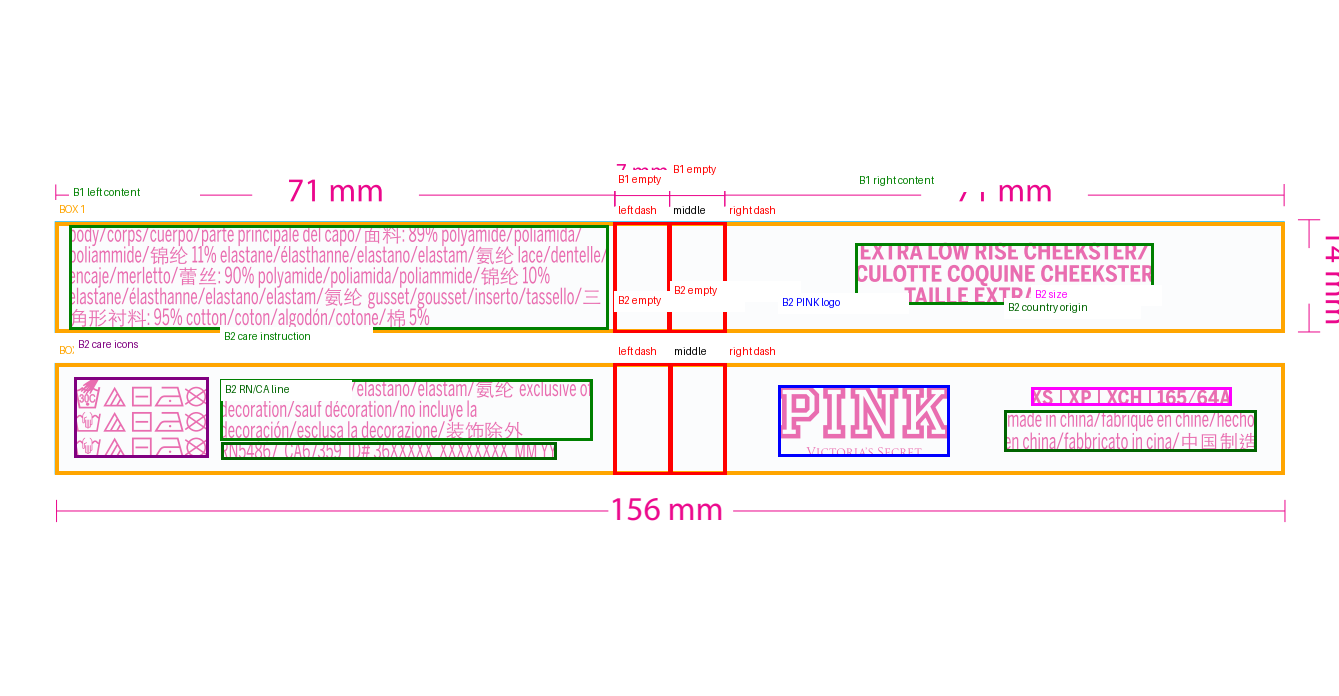

In [7]:
from pathlib import Path
import pypdfium2 as pdfium
from PIL import ImageDraw
from IPython.display import display, Image

output_dir = Path("../annotated image")
output_dir.mkdir(exist_ok=True)

dpi = 200
scale = dpi / 72

def render_pdf_page(pdf_path, dpi=200):
    pdf = pdfium.PdfDocument(str(pdf_path))
    page = pdf[0]
    bitmap = page.render(scale=dpi / 72)
    return bitmap.to_pil().convert("RGB")

def to_px_bbox(bbox):
    x0, top, x1, bottom = bbox
    return tuple(round(value * scale) for value in (x0, top, x1, bottom))

def draw_box(draw, bbox, color, label, width=4, label_offset=0):
    x0, y0, x1, y1 = to_px_bbox(bbox)

    draw.rectangle((x0, y0, x1, y1), outline=color, width=width)

    label_width = max(130, len(label) * 8)
    label_y = max(0, y0 - 22 - label_offset)

    draw.rectangle((x0, label_y, x0 + label_width, label_y + 20), fill="white")
    draw.text((x0 + 4, label_y + 3), label, fill=color)

def bbox_from_mm(relative_bbox, box):
    if relative_bbox is None:
        return None

    return (
        box["x0"] + (relative_bbox["x0_mm"] / PT_TO_MM),
        box["top"] + (relative_bbox["top_mm"] / PT_TO_MM),
        box["x0"] + (relative_bbox["x1_mm"] / PT_TO_MM),
        box["top"] + (relative_bbox["bottom_mm"] / PT_TO_MM),
    )

def annotate_master_structure(master_pdf_path, output_dir, dpi=200):
    image = render_pdf_page(master_pdf_path, dpi=dpi)
    draw = ImageDraw.Draw(image)

    with pdfplumber.open(master_pdf_path) as pdf:
        page = pdf.pages[0]
        boxes = get_label_boxes(page)

        for box_data in master_structure:
            box_no = box_data["box_no"]
            box = boxes[box_no - 1]

            guides = get_vertical_guides(page, box)
            left_dash, middle_line, right_dash = guides[:3]

            # Draw label box
            box_bbox = (box["x0"], box["top"], box["x1"], box["bottom"])
            draw_box(draw, box_bbox, "orange", f"BOX {box_no}", width=4)

            # Draw guide lines
            for label, x, color in [
                ("left dash", left_dash, "red"),
                ("middle", middle_line, "black"),
                ("right dash", right_dash, "red"),
            ]:
                x_px = round(x * scale)
                y0_px = round(box["top"] * scale)
                y1_px = round(box["bottom"] * scale)

                draw.line((x_px, y0_px, x_px, y1_px), fill=color, width=3)
                draw.text((x_px + 4, y0_px - 18), label, fill=color)

            sections = box_data["sections"]

            if box_no == 1:
                draw_plan = [
                    ("left_content", "green", "B1 left content"),
                    ("middle_left_empty", "red", "B1 empty"),
                    ("middle_right_empty", "red", "B1 empty"),
                    ("right_content", "green", "B1 right content"),
                ]

            elif box_no == 2:
                draw_plan = [
                    ("care_icons", "purple", "B2 care icons"),
                    ("care_instruction_text", "green", "B2 care instruction"),
                    ("rn_ca_line", "darkgreen", "B2 RN/CA line"),
                    ("middle_left_empty", "red", "B2 empty"),
                    ("middle_right_empty", "red", "B2 empty"),
                    ("logo", "blue", "B2 PINK logo"),
                    ("size", "magenta", "B2 size"),
                    ("country_of_origin", "darkgreen", "B2 country origin"),
                ]

            else:
                draw_plan = []

            label_offset = 20

            for section_key, color, label in draw_plan:
                section = sections.get(section_key)

                if not section:
                    continue

                # Empty middle sections do not have bbox in master_structure,
                # so draw them directly from guide lines.
                if section_key == "middle_left_empty":
                    bbox = (left_dash, box["top"], middle_line, box["bottom"])

                elif section_key == "middle_right_empty":
                    bbox = (middle_line, box["top"], right_dash, box["bottom"])

                else:
                    bbox_mm = section.get("bbox")
                    if bbox_mm is None:
                        continue
                    bbox = bbox_from_mm(bbox_mm, box)

                draw_box(
                    draw=draw,
                    bbox=bbox,
                    color=color,
                    label=label,
                    width=3,
                    label_offset=label_offset,
                )

                label_offset += 10

        full_path = output_dir / "master_structure_final_annotated_full.png"
        image.save(full_path)

        crop_x0 = min(box["x0"] for box in boxes) - 20
        crop_top = min(box["top"] for box in boxes) - 80
        crop_x1 = max(box["x1"] for box in boxes) + 20
        crop_bottom = max(box["bottom"] for box in boxes) + 80

        crop = image.crop(to_px_bbox((crop_x0, crop_top, crop_x1, crop_bottom)))

        crop_path = output_dir / "master_structure_final_annotated_crop.png"
        crop.save(crop_path)

    return full_path, crop_path

full_image_path, crop_image_path = annotate_master_structure(
    master_pdf_path=master_pdf_path,
    output_dir=output_dir,
    dpi=dpi,
)

print("Full image saved:", full_image_path)
print("Crop image saved:", crop_image_path)

display(Image(filename=str(crop_image_path)))